# CICIDS2017 IDS - Behavioral Detection with LAE-XAI-IDS

**Model:** Latency-Aware Ensemble Explainable AI-IDS (**LAE-XAI-IDS**)

Pipeline

1. **Leakage audit** - duplicate overlap, raw/clean depth-3 probe, identifier features removed.
2. **Seven class-balanced baselines** on behavioral features only.
3. **Latency-aware ensemble** - members with p99 <= 10 ms; combiner chosen by OOF F1.
4. **LAE-XAI-IDS** - SHAP top features (tau = 0.95 cumulative importance) retrain the ensemble.
5. **Ablation** - XAI-IDS tau sweep, no-latency-cap, single model, no class balancing.
6. Comparison tables, confusion matrices, efficiency charts, per-class F1, SHAP panels.
7. **Cross-dataset SHAP comparison** - CICEVSE2024 vs CICIDS2017.

> All models share the same cleaned feature set. The CICIDS2017 test split is ~80% BENIGN, so Weighted F1 saturates; Macro F1 is the headline metric and the published table uses a class-capped eval split.


In [1]:
# !pip install lightgbm xgboost catboost shap seaborn scikit-learn pandas matplotlib optuna

import warnings
warnings.filterwarnings("ignore")

import os, time, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline
from sklearn.base import clone, BaseEstimator, ClassifierMixin
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score,
                             confusion_matrix, classification_report)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

np.random.seed(42)
RANDOM_STATE = 42
N_SPLITS_CV = 3
SHAP_CUM_THRESHOLD = 0.95
DATASET_TAG = "CICIDS2017"
LAE_NAME = "LAE-XAI-IDS"
ENSEMBLE_NAME = "AutoML-Ensemble"
PROPOSED_NAME = LAE_NAME
LAE_FULL_NAME = "Latency-Aware Ensemble Explainable AI-IDS"

LATENCY_REPEATS = 5
LATENCY_ROWS = 200
SVM_MAX_TRAIN_SAMPLES = 20000
ENSEMBLE_LATENCY_CAP_MS = 10.0
TOP_K = 3
RUN_OPTUNA = True
N_TRIALS_BASELINE = 20
N_TRIALS_SLOW = 10
ABLATION_TAUS = [0.80, 0.90, 0.95, 0.99]
ABLATION_INCLUDE_UNBALANCED = True
DROP_OVERLAP_ROWS = True

EVAL_MAX_PER_CLASS = 2000
SCORE_FULL_TEST = True
FULLTEST_SKIP = ("SVM", "Logistic Regression")

TRAIN_CSV = "Data/CICIDS2017_training_set.csv"
TEST_CSV = "Data/CICIDS2017_test_set.csv"
# Semantic names for the 7-class grouping used in this dump.
CICIDS2017_CLASS_NAMES = {
    0: "BENIGN", 1: "Bot", 2: "Brute Force", 3: "DoS/DDoS",
    4: "Infiltration", 5: "PortScan", 6: "Web Attack",
}
plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 12, "figure.titlesize": 18,
})

# ------------------------------------------------------------
# Output helpers - every figure is saved as PNG, and the values
# behind it as CSV, so any plot can be rebuilt later.
# ------------------------------------------------------------
def save_figure(fig, name, dpi=200):
    path = f"{DATASET_TAG}_{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", path)
    return path

def save_plot_data(obj, name):
    df = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
    path = f"{DATASET_TAG}_{name}_plotdata.csv"
    df.to_csv(path)
    print("Saved plot data:", path)
    return df

print("Config ready. Dataset:", DATASET_TAG, "| LAE model:", LAE_NAME)


Config ready. Dataset: CICIDS2017 | LAE model: LAE-XAI-IDS


In [2]:
training_data = pd.read_csv(TRAIN_CSV, low_memory=False)
testing_data = pd.read_csv(TEST_CSV, low_memory=False)

# CICFlowMeter dumps often have leading spaces in column names.
training_data.columns = training_data.columns.str.strip()
testing_data.columns = testing_data.columns.str.strip()
assert list(training_data.columns) == list(testing_data.columns), "Train/test column mismatch"
assert "Label" in training_data.columns, "Expected a Label column"

label_encoder = LabelEncoder()
training_data["Label"] = label_encoder.fit_transform(training_data["Label"])
testing_data["Label"] = label_encoder.transform(testing_data["Label"])
class_names = [CICIDS2017_CLASS_NAMES.get(int(c), str(c)) for c in label_encoder.classes_]

# Class-aware sampling on TRAIN only: keep class in full if count < 10,000, else 2%.
class_counts = training_data["Label"].value_counts()
samples_to_keep = class_counts.apply(lambda x: x if x < 10000 else int(x * 0.02))
# List comprehension keeps the Label column (pandas>=3 drops grouping
# columns from groupby().apply()).
balanced_training_data = pd.concat([
    g.sample(n=int(samples_to_keep[key]), random_state=RANDOM_STATE)
    for key, g in training_data.groupby("Label")
]).reset_index(drop=True)

X_train_raw = balanced_training_data.drop(columns=["Label"]).reset_index(drop=True)
y_train = balanced_training_data["Label"].reset_index(drop=True)
X_test_raw = testing_data.drop(columns=["Label"]).reset_index(drop=True)
y_test = testing_data["Label"].reset_index(drop=True)

print("Raw training shape:", X_train_raw.shape, " Test shape:", X_test_raw.shape)
print("Classes:", class_names)
print("Train class counts after sampling:")
print(y_train.value_counts().sort_index())
print("\nFull-train class counts (before sampling):")
print(class_counts.sort_index())


Raw training shape: (48569, 77)  Test shape: (566149, 77)
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DoS/DDoS', 'Infiltration', 'PortScan', 'Web Attack']
Train class counts after sampling:
Label
0    36369
1     1573
2      221
3     6091
4       29
5     2542
6     1744
Name: count, dtype: int64

Full-train class counts (before sampling):
Label
0    1818477
1       1573
2      11068
3     304559
4         29
5     127144
6       1744
Name: count, dtype: int64


In [3]:
# ------------------------------------------------------------
# Leakage cleaning - SAME feature set for every model.
# ------------------------------------------------------------
def _norm_name(c):
    return str(c).strip().lower().replace(" ", "_").replace("-", "_")

IDENTIFIER_NAMES = {
    "src_ip", "dst_ip", "src_mac", "dst_mac", "src_oui", "dst_oui",
    "source_ip", "destination_ip", "srcip", "dstip",
    "source_mac", "destination_mac",
    "flow_id", "flowid", "timestamp", "date",
    "destination_port", "dest_port", "dst_port", "dstport",
    # CICIDS OS/stack identity (analog of src_oui / dst_mac)
    "init_win_bytes_forward", "init_win_bytes_backward",
    "init_win_bytes_fwd", "init_win_bytes_bwd",
    "min_seg_size_forward", "min_seg_size_fwd",
}

SUSPECT_FEATURES = [c for c in X_train_raw.columns if (
    _norm_name(c) in IDENTIFIER_NAMES
    or str(c).endswith("_first_seen_ms")
    or str(c).endswith("_last_seen_ms")
)]
print("Removing identifier/timestamp/port-fingerprint features:")
if SUSPECT_FEATURES:
    for f in SUSPECT_FEATURES:
        print("  -", f)
else:
    print("  (none present in this dump)")


def sanitize_columns(df):
    """LightGBM/XGBoost reject spaces and dots in feature names."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str).str.strip()
          .str.replace(r"[^\w]+", "_", regex=True)
          .str.replace(r"_+", "_", regex=True)
          .str.strip("_")
    )
    return df


clean_cols = [c for c in X_train_raw.columns if c not in SUSPECT_FEATURES]
X_train = sanitize_columns(X_train_raw[clean_cols].copy().reset_index(drop=True))
X_test = sanitize_columns(X_test_raw[clean_cols].copy().reset_index(drop=True))
assert list(X_train.columns) == list(X_test.columns)

# Numeric hygiene (raw dumps use inf in ratio features).
for _df in (X_train, X_test):
    _df.replace([np.inf, -np.inf], np.nan, inplace=True)
if X_train.isna().any().any() or X_test.isna().any().any():
    med = X_train.median(numeric_only=True)
    X_train.fillna(med, inplace=True)
    X_test.fillna(med, inplace=True)

# Drop constants and exact duplicate columns. Computed on TRAIN only.
nunique = X_train.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
dup_cols = []
seen = {}
for col in X_train.columns:
    key = pd.util.hash_pandas_object(X_train[col], index=False).to_numpy().tobytes()
    if key in seen:
        dup_cols.append(col)
    else:
        seen[key] = col
drop_extra = [c for c in (constant_cols + dup_cols) if c in X_train.columns]
if drop_extra:
    print("Dropping constant/duplicate columns:")
    for f in drop_extra:
        print("  -", f)
    X_train = X_train.drop(columns=drop_extra)
    X_test = X_test.drop(columns=drop_extra)
else:
    print("No constant/duplicate columns dropped.")

print(f"\nFeature set: {X_train.shape[1]}/{X_train_raw.shape[1]} behavioral features retained.")
print("Feature names:")
print(list(X_train.columns))


Removing identifier/timestamp/port-fingerprint features:
  - Init_Win_bytes_forward
  - Init_Win_bytes_backward
  - min_seg_size_forward
Dropping constant/duplicate columns:
  - Flow_Bytes_s
  - Flow_Packets_s
  - Bwd_PSH_Flags
  - Bwd_URG_Flags
  - Fwd_Avg_Bytes_Bulk
  - Fwd_Avg_Packets_Bulk
  - Fwd_Avg_Bulk_Rate
  - Bwd_Avg_Bytes_Bulk
  - Bwd_Avg_Packets_Bulk
  - Bwd_Avg_Bulk_Rate
  - Flow_Packets_s
  - Bwd_PSH_Flags
  - Bwd_URG_Flags
  - SYN_Flag_Count
  - CWE_Flag_Count
  - Avg_Fwd_Segment_Size
  - Fwd_Header_Length_1
  - Fwd_Avg_Bytes_Bulk
  - Fwd_Avg_Packets_Bulk
  - Fwd_Avg_Bulk_Rate
  - Bwd_Avg_Bytes_Bulk
  - Bwd_Avg_Packets_Bulk
  - Bwd_Avg_Bulk_Rate
  - Subflow_Fwd_Packets
  - Subflow_Bwd_Packets

Feature set: 58/77 behavioral features retained.
Feature names:
['Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets', 'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Leng

## Leakage diagnostics

1. **Raw vs clean depth-3 probe** - if identifiers remain, a stump tree sits near 99.99%.
2. **Duplicate overlap** - test rows identical to a train row (flow-level split artifact). Overlapping test rows are removed so no model can memorize copies.
3. **Clean depth-3 probe** - trivial separability check on the behavioral feature set used by every model.


In [4]:
# Raw probe: same stump on the *un-cleaned* matrix (identifiers still in).
X_train_probe_raw = sanitize_columns(X_train_raw.copy())
X_test_probe_raw = sanitize_columns(X_test_raw.copy())
for _df in (X_train_probe_raw, X_test_probe_raw):
    _df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for c in _df.columns:
        _df[c] = pd.to_numeric(_df[c], errors="coerce")
med_raw = X_train_probe_raw.median(numeric_only=True)
X_train_probe_raw.fillna(med_raw, inplace=True)
X_test_probe_raw.fillna(med_raw, inplace=True)

raw_probe = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_train_probe_raw, y_train)
raw_probe_acc = accuracy_score(y_test, raw_probe.predict(X_test_probe_raw))
raw_importances = pd.Series(raw_probe.feature_importances_,
                            index=X_train_probe_raw.columns).sort_values(ascending=False)
print(f"Depth-3 tree test accuracy (RAW features, identifiers in): {raw_probe_acc*100:.2f}%")
print("Top RAW probe features (leakage suspects if these are ports/IPs/timestamps):")
print(raw_importances.head(5).round(4))

# Duplicate overlap on the CLEAN feature set that models will actually see.
tr_h = pd.util.hash_pandas_object(X_train, index=False)
te_h = pd.util.hash_pandas_object(X_test, index=False)
train_hash_set = set(tr_h.to_numpy())
overlap_mask = pd.Series(te_h).isin(train_hash_set)
n_overlap_rows = int(overlap_mask.sum())
n_unique_test = int(pd.Series(te_h).nunique())
n_shared_unique = len(train_hash_set & set(pd.Series(te_h).unique()))
overlap_pct = 100.0 * n_shared_unique / max(n_unique_test, 1)
print(f"\nUnique train rows: {X_train.drop_duplicates().shape[0]}, unique test rows: {n_unique_test}")
print(f"Unique test hashes also in train: {n_shared_unique} ({overlap_pct:.2f}% of unique test)")
print(f"Test rows identical to a train row: {n_overlap_rows} / {len(X_test)}")
LEAKAGE_SUSPECTED = overlap_pct > 10.0
print(">>> Flow-level overlap detected - memorization inflates scores."
      if LEAKAGE_SUSPECTED else ">>> Overlap is low; most flows are disjoint.")

if DROP_OVERLAP_ROWS and n_overlap_rows > 0:
    keep = ~overlap_mask.to_numpy()
    X_test = X_test.iloc[keep].reset_index(drop=True)
    y_test = y_test.iloc[keep].reset_index(drop=True)
    print(f"Disjoint test set for ALL models: {X_test.shape[0]} rows "
          f"(removed {n_overlap_rows} overlapping copies).")
else:
    print("No overlapping test rows to remove.")

# Full disjoint test (before any class cap) - used for the supplementary table.
X_test_full = X_test.copy().reset_index(drop=True)
y_test_full = y_test.reset_index(drop=True)


def cap_eval_split(X, y, max_per_class, random_state):
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)
    rng = np.random.RandomState(random_state)
    parts = []
    for c in sorted(y.unique()):
        c_idx = y.index[y == c].to_numpy()
        n = min(int(max_per_class), len(c_idx))
        parts.append(rng.choice(c_idx, size=n, replace=False))
    idx = np.concatenate(parts)
    rng.shuffle(idx)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


if EVAL_MAX_PER_CLASS:
    print("\nFull disjoint test class counts (before cap):")
    print(pd.Series(y_test_full).value_counts().sort_index())
    X_test, y_test = cap_eval_split(X_test_full, y_test_full, EVAL_MAX_PER_CLASS, RANDOM_STATE)
    print(f"Published eval split: {X_test.shape[0]} rows, max {EVAL_MAX_PER_CLASS} per class")
    print(pd.Series(y_test).value_counts().sort_index())
else:
    print("\nNo class cap (EVAL_MAX_PER_CLASS is None) - full disjoint test is the headline split.")
print("Latency uses 200 random rows from the published split (same protocol).")


Depth-3 tree test accuracy (RAW features, identifiers in): 92.58%
Top RAW probe features (leakage suspects if these are ports/IPs/timestamps):
Bwd_Packet_Length_Std      0.5331
Average_Packet_Size        0.2502
Packet_Length_Std          0.1784
Init_Win_bytes_backward    0.0372
Bwd_IAT_Total              0.0011
dtype: float64

Unique train rows: 39761, unique test rows: 429646
Unique test hashes also in train: 3823 (0.89% of unique test)
Test rows identical to a train row: 119172 / 566149
>>> Overlap is low; most flows are disjoint.
Disjoint test set for ALL models: 446977 rows (removed 119172 overlapping copies).

Full disjoint test class counts (before cap):
Label
0    378637
1       246
2      1991
3     65207
4         7
5       486
6       403
Name: count, dtype: int64
Published eval split: 7133 rows, max 2000 per class
Label
0    2000
1     246
2    1991
3    2000
4       7
5     486
6     403
Name: count, dtype: int64
Latency uses 200 random rows from the published split (same p

In [5]:
probe = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)
probe_acc = accuracy_score(y_test, probe.predict(X_test))
importances = pd.Series(probe.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)
print(f"Depth-3 tree test accuracy (CLEAN behavioral features): {probe_acc*100:.2f}%")
print(f"Raw-vs-clean gap: {(raw_probe_acc - probe_acc)*100:.2f} percentage points")
print("\nTop features used by the CLEAN probe:")
print(importances.head(5).round(4))
if raw_probe_acc > 0.95 and probe_acc < raw_probe_acc - 0.05:
    print("\n>>> Identifiers were carrying the 99.99%-style score. Clean features are used from here.")
elif probe_acc > 0.95:
    print("\n>>> Even on behavioral features, 3 splits nearly solve the task. Report Macro F1.")
else:
    print("\n>>> Clean features do not allow trivial memorization - good.")


Depth-3 tree test accuracy (CLEAN behavioral features): 52.10%
Raw-vs-clean gap: 40.49 percentage points

Top features used by the CLEAN probe:
Bwd_Packet_Length_Std     0.5373
Average_Packet_Size       0.2521
Packet_Length_Variance    0.1742
Bwd_Packet_Length_Mean    0.0278
Packet_Length_Std         0.0056
dtype: float64

>>> Clean features do not allow trivial memorization - good.


## Seven class-balanced baselines (identical feature set for all)

Fixed sensible defaults plus class balancing for imbalance; SVM capped at 20,000 stratified rows.
With `RUN_OPTUNA=True` the Optuna cell tunes and refits these models, and those refits feed the
ensemble and LAE-XAI-IDS.


In [6]:
class SubsampledClassifier(BaseEstimator, ClassifierMixin):
    """Fits a slow estimator on a stratified subsample; predicts on whatever it is given."""
    def __init__(self, base_estimator=None, max_train_samples=20000, random_state=42):
        self.base_estimator = base_estimator
        self.max_train_samples = max_train_samples
        self.random_state = random_state
    def fit(self, X, y):
        X_fit, y_fit = X, y
        if self.max_train_samples is not None and len(X) > self.max_train_samples:
            X_fit, _, y_fit, _ = train_test_split(X, y, train_size=self.max_train_samples,
                                                  stratify=y, random_state=self.random_state)
        self.estimator_ = clone(self.base_estimator)
        self.estimator_.fit(X_fit, y_fit)
        self.classes_ = self.estimator_.classes_
        return self
    def predict(self, X):  return self.estimator_.predict(X)
    def predict_proba(self, X):  return self.estimator_.predict_proba(X)


class BalancedXGBClassifier(xgb.XGBClassifier):
    """Multiclass XGBoost with inverse-frequency sample weights."""
    def fit(self, X, y, **kwargs):
        if kwargs.get("sample_weight") is None:
            kwargs["sample_weight"] = compute_sample_weight("balanced", y)
        return super().fit(X, y, **kwargs)


def build_baselines(balanced=True):
    cw = "balanced" if balanced else None
    xgb_cls = BalancedXGBClassifier if balanced else xgb.XGBClassifier
    return {
        "Decision Tree": DecisionTreeClassifier(
            max_depth=20, min_samples_leaf=2, criterion="entropy",
            class_weight=cw, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=None, min_samples_leaf=2,
            max_features="sqrt", class_weight=cw, n_jobs=-1, random_state=RANDOM_STATE),
        "XGBoost": xgb_cls(
            n_estimators=200, learning_rate=0.1, max_depth=8, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist",
            eval_metric="mlogloss", n_jobs=-1, random_state=RANDOM_STATE, verbosity=0),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.1, num_leaves=63, max_depth=-1,
            min_child_samples=1, subsample=0.8, subsample_freq=1,
            colsample_bytree=0.8, class_weight=cw,
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1),
        "CatBoost": CatBoostClassifier(
            iterations=200, learning_rate=0.1, depth=8, verbose=0,
            auto_class_weights=("Balanced" if balanced else None),
            random_state=RANDOM_STATE, allow_writing_files=False),
        "SVM": SubsampledClassifier(
            base_estimator=Pipeline([("scaler", StandardScaler()),
                                     ("clf", SVC(kernel="rbf", C=10.0, gamma="scale",
                                                 probability=True, class_weight=cw,
                                                 random_state=RANDOM_STATE))]),
            max_train_samples=SVM_MAX_TRAIN_SAMPLES, random_state=RANDOM_STATE),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=1.0, max_iter=3000, n_jobs=-1,
                                       class_weight=cw, random_state=RANDOM_STATE))]),
    }

BASELINE_NAMES = ["Decision Tree", "Random Forest", "XGBoost", "LightGBM",
                  "CatBoost", "SVM", "Logistic Regression"]
print("Baseline builders ready (class-balanced default).")


Baseline builders ready (class-balanced default).


## Evaluation helpers - honest per-sample latency

Single-row p99 latency (not batch-divided), batch throughput, pickle size.


In [7]:
def model_size_mb(model):
    return len(pickle.dumps(model)) / (1024 ** 2)


def per_sample_p99_latency_ms(model, X_eval, n_rows=LATENCY_ROWS, n_repeats=LATENCY_REPEATS):
    X_eval = X_eval.sample(n=min(n_rows, len(X_eval)), random_state=RANDOM_STATE)
    rows = [X_eval.iloc[[i]] for i in range(len(X_eval))]
    _ = model.predict(rows[0])  # warm-up
    lats = []
    for _ in range(n_repeats):
        for r in rows:
            t0 = time.perf_counter()
            model.predict(r)
            lats.append((time.perf_counter() - t0) * 1000.0)
    return float(np.percentile(lats, 99))


def evaluate_on_test(model, X_te, y_te):
    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    infer_time = time.perf_counter() - t0

    acc = accuracy_score(y_te, y_pred)
    prec, rec, w_f1, _ = precision_recall_fscore_support(
        y_te, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_te, y_pred, average="macro", zero_division=0)

    return {
        "y_pred": y_pred, "accuracy": acc, "precision": prec, "recall": rec,
        "weighted_f1": w_f1, "macro_f1": macro_f1,
        "batch_latency_ms": infer_time / len(X_te) * 1000.0,
        "p99_latency_ms": per_sample_p99_latency_ms(model, X_te),
        "model_size_mb": model_size_mb(model),
        "confusion_matrix": confusion_matrix(y_te, y_pred),
    }

print("Evaluation helpers ready.")


Evaluation helpers ready.


In [8]:
results, fitted_models, train_times = {}, {}, {}

if RUN_OPTUNA:
    print("RUN_OPTUNA=True - baseline fit deferred to the Optuna cell; "
          "tuned models feed the ensemble and LAE-XAI-IDS.")
else:
    for name in BASELINE_NAMES:
        print("Fitting:", name, flush=True)
        model = build_baselines()[name]
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        train_times[name] = time.perf_counter() - t0
        results[name] = evaluate_on_test(model, X_test, y_test)
        fitted_models[name] = model
        print(f"  Test F1={results[name]['weighted_f1']:.4f}  "
              f"MacroF1={results[name]['macro_f1']:.4f}  "
              f"P99={results[name]['p99_latency_ms']:.3f}ms  "
              f"Size={results[name]['model_size_mb']:.3f}MB  "
              f"TrainTime={train_times[name]:.1f}s", flush=True)
    print("\nAll baselines fitted and evaluated.")


RUN_OPTUNA=True - baseline fit deferred to the Optuna cell; tuned models feed the ensemble and LAE-XAI-IDS.


## Latency-aware ensemble

Top-`TOP_K` members ranked by weighted F1 **among models with p99 latency <= 10 ms**, so the
ensemble stays deployable. OOF probabilities computed once per member; combiner chosen by OOF F1.


In [9]:
skf = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE)
classes_ref = np.unique(np.asarray(y_train))
y_train_arr = np.asarray(y_train)
_ENSEMBLE_CACHE = {}


class PrefittedEnsemble:
    def __init__(self, base_models, names, kind, weights=None, meta_learner=None):
        self.base_models, self.names = base_models, names
        self.kind, self.weights = kind, weights
        self.meta_learner = meta_learner
        self.classes_ = classes_ref
    def predict_proba(self, X):
        p = [self.base_models[n].predict_proba(X) for n in self.names]
        if self.kind.startswith("Voting"):
            acc = sum(w * pi for w, pi in zip(self.weights, p))
            return acc / np.sum(self.weights)
        return self.meta_learner.predict_proba(np.hstack(p))
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


def build_ensemble(members, features):
    """OOF-select the combiner, refit members on `features`, evaluate on the published split."""
    oof = {n: cross_val_predict(clone(fitted_models[n]), X_train[features], y_train,
                                cv=skf, method="predict_proba", n_jobs=-1) for n in members}

    def vote(weights):
        return classes_ref[np.argmax(sum(w * oof[n] for w, n in zip(weights, members)), axis=1)]

    n_mem = len(members)
    uniform_f1 = f1_score(y_train_arr, vote([1.0] * n_mem), average="weighted", zero_division=0)
    cv_f1s = [results[n]["weighted_f1"] for n in members]
    w_f1_weights = [f / sum(cv_f1s) for f in cv_f1s]
    weighted_f1_oof = f1_score(y_train_arr, vote(w_f1_weights), average="weighted", zero_division=0)
    meta_X = np.hstack([oof[n] for n in members])
    oof_meta_pred = cross_val_predict(
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        meta_X, y_train_arr, cv=skf, n_jobs=-1)
    stacking_f1 = f1_score(y_train_arr, oof_meta_pred, average="weighted", zero_division=0)
    print(f"  OOF: uniform={uniform_f1:.4f} f1-weighted={weighted_f1_oof:.4f} stacking={stacking_f1:.4f}")

    candidates = {"Voting-Uniform": (uniform_f1, [1.0] * n_mem),
                  "Voting-F1Weighted": (weighted_f1_oof, w_f1_weights),
                  "Stacking": (stacking_f1, None)}
    kind = max(candidates, key=lambda k: candidates[k][0])
    oof_f1, weights = candidates[kind]
    bases = {n: clone(fitted_models[n]).fit(X_train[features], y_train) for n in members}
    meta_final = (LogisticRegression(max_iter=3000, class_weight="balanced",
                                     random_state=RANDOM_STATE)
                  .fit(meta_X, y_train_arr) if kind == "Stacking" else None)
    model = PrefittedEnsemble(bases, members, kind, weights, meta_final)
    metrics = evaluate_on_test(model, X_test[features], y_test)
    metrics["oof_weighted_f1"] = oof_f1
    return model, metrics, kind


def fit_latency_aware_ensemble():
    global top_names, ensemble_type, ens_weights, ensemble_oof_f1, automl_ensemble
    eligible = [n for n in BASELINE_NAMES if results[n]["p99_latency_ms"] <= ENSEMBLE_LATENCY_CAP_MS]
    print("Latency-eligible models:", eligible)
    ranked = sorted(((n, results[n]["weighted_f1"]) for n in eligible),
                    key=lambda kv: kv[1], reverse=True)
    top_names = [n for n, _ in ranked[:TOP_K]]
    print("Top members:", top_names)
    automl_ensemble, metrics, ensemble_type = build_ensemble(top_names, list(X_train.columns))
    ensemble_oof_f1 = metrics["oof_weighted_f1"]
    ens_weights = None
    results[ENSEMBLE_NAME] = metrics
    fitted_models[ENSEMBLE_NAME] = automl_ensemble
    _ENSEMBLE_CACHE[("full", tuple(top_names))] = (automl_ensemble, metrics, ensemble_type)
    print(f"{ENSEMBLE_NAME} ({ensemble_type}) Test F1={metrics['weighted_f1']:.4f} "
          f"MacroF1={metrics['macro_f1']:.4f}")
    return automl_ensemble


if RUN_OPTUNA:
    print("RUN_OPTUNA=True - ensemble deferred until tuned baselines are ready.")
else:
    fit_latency_aware_ensemble()


RUN_OPTUNA=True - ensemble deferred until tuned baselines are ready.


In [10]:
# ============================================================
# Optuna variant - tune every baseline, refit, rebuild ensemble
# ============================================================
# !pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def cv_weighted_f1(estimator, X_tr, y_tr, n_splits=N_SPLITS_CV):
    """Stratified-CV weighted F1 - tuning objective for all baselines."""
    _skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    preds = cross_val_predict(estimator, X_tr, y_tr, cv=_skf, n_jobs=-1)
    return f1_score(y_tr, preds, average="weighted", zero_division=0)


def build_estimator(name, trial):
    if name == "Decision Tree":
        return DecisionTreeClassifier(
            max_depth=trial.suggest_int("max_depth", 3, 30),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 40),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
            criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
            class_weight="balanced", random_state=RANDOM_STATE)
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 400, step=50),
            max_depth=trial.suggest_categorical("max_depth", [None, 10, 15, 20, 30]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    if name == "XGBoost":
        return BalancedXGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 400, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            tree_method="hist", eval_metric="mlogloss",
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
    if name == "LightGBM":
        return lgb.LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 400, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            num_leaves=trial.suggest_int("num_leaves", 15, 127),
            max_depth=trial.suggest_categorical("max_depth", [-1, 6, 8, 10, 12]),
            min_child_samples=trial.suggest_int("min_child_samples", 1, 50),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            subsample_freq=1,
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1)
    if name == "CatBoost":
        return CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 100, 400, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            depth=trial.suggest_int("depth", 4, 10),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
            auto_class_weights="Balanced",
            random_state=RANDOM_STATE, verbose=0, allow_writing_files=False)
    if name == "SVM":
        svc = SVC(
            C=trial.suggest_float("C", 1e-2, 100.0, log=True),
            gamma=trial.suggest_float("gamma", 1e-4, 1.0, log=True),
            kernel="rbf", probability=True, class_weight="balanced",
            random_state=RANDOM_STATE)
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", svc)])
        return SubsampledClassifier(
            base_estimator=pipe, max_train_samples=SVM_MAX_TRAIN_SAMPLES, random_state=RANDOM_STATE)
    if name == "Logistic Regression":
        return LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 100.0, log=True),
            class_weight="balanced", max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE)
    raise ValueError(name)


NEEDS_SCALING = {"Logistic Regression"}


def make_pipeline_if_needed(name, estimator):
    if name in NEEDS_SCALING:
        return Pipeline([("scaler", StandardScaler()), ("clf", estimator)])
    return estimator


def tune_model(name, X_tr, y_tr, n_trials=None):
    if n_trials is None:
        n_trials = N_TRIALS_SLOW if name in ("SVM",) else N_TRIALS_BASELINE

    def objective(trial):
        est = make_pipeline_if_needed(name, build_estimator(name, trial))
        return cv_weighted_f1(est, X_tr, y_tr)

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_trial


class _FixedTrial:
    """Replays a completed trial's chosen hyperparameters without re-searching."""
    def __init__(self, params):
        self.params = params
    def suggest_int(self, k, *a, **kw): return self.params[k]
    def suggest_float(self, k, *a, **kw): return self.params[k]
    def suggest_categorical(self, k, *a, **kw): return self.params[k]


print(f"Optuna ready - {N_TRIALS_BASELINE} trials per baseline "
      f"({N_TRIALS_SLOW} for SVM). RUN_OPTUNA={RUN_OPTUNA}")

tuned_rows = []
if RUN_OPTUNA:
    results, fitted_models, train_times = {}, {}, {}
    for name in BASELINE_NAMES:
        print("Tuning:", name, flush=True)
        best = tune_model(name, X_train, y_train)
        tuned_rows.append({"model": name,
                           "cv_weighted_f1": float(best.value),
                           "params": json.dumps(best.params)})
        print(f"  CV F1={best.value:.4f}  params={best.params}", flush=True)
        model = make_pipeline_if_needed(name, build_estimator(name, _FixedTrial(best.params)))
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        train_times[name] = time.perf_counter() - t0
        results[name] = evaluate_on_test(model, X_test, y_test)
        fitted_models[name] = model
        print(f"  Test F1={results[name]['weighted_f1']:.4f}  "
              f"MacroF1={results[name]['macro_f1']:.4f}  "
              f"P99={results[name]['p99_latency_ms']:.3f}ms  "
              f"TrainTime={train_times[name]:.1f}s", flush=True)
    pd.DataFrame(tuned_rows).to_csv(f"{DATASET_TAG}_tuned_hyperparameters.csv", index=False)
    with open(f"{DATASET_TAG}_tuned_params.json", "w") as f:
        json.dump(tuned_rows, f, indent=2)
    print("Saved tuned hyperparameters. Rebuilding latency-aware ensemble ...")
    fit_latency_aware_ensemble()
else:
    print("Skipping Optuna search. Set RUN_OPTUNA=True to tune and refit all models.")


Optuna ready - 20 trials per baseline (10 for SVM). RUN_OPTUNA=True
Tuning: Decision Tree
  CV F1=0.9542  params={'max_depth': 24, 'min_samples_split': 9, 'min_samples_leaf': 1, 'criterion': 'entropy'}
  Test F1=0.9792  MacroF1=0.9793  P99=1.607ms  TrainTime=1.4s
Tuning: Random Forest
  CV F1=0.9611  params={'n_estimators': 350, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Test F1=0.9819  MacroF1=0.9824  P99=71.793ms  TrainTime=2.6s
Tuning: XGBoost
  CV F1=0.9596  params={'n_estimators': 250, 'learning_rate': 0.10478335897075117, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.6051440653010286, 'colsample_bytree': 0.8868725063429692, 'reg_lambda': 0.0019003685150317381}
  Test F1=0.9823  MacroF1=0.9826  P99=5.847ms  TrainTime=10.0s
Tuning: LightGBM
  CV F1=0.9629  params={'n_estimators': 400, 'learning_rate': 0.04897571013167255, 'num_leaves': 78, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8027105027486668, 'colsample_byt

## Proposed LAE-XAI-IDS - SHAP-driven feature selection + latency-aware ensemble

SHAP global importance from the strongest tree (by Macro F1) ranks the behavioral features. The top
features covering tau = 0.95 cumulative importance form the reduced subset; the winning ensemble is
retrained on it. The per-class SHAP matrix is saved for the cross-dataset comparison.


In [11]:
TREE_NAMES = ["Decision Tree", "Random Forest", "XGBoost", "LightGBM", "CatBoost"]
best_tree_name = max((n for n in TREE_NAMES if n in results), key=lambda n: results[n]["macro_f1"])
print("Representative tree model for SHAP (highest Macro F1):", best_tree_name)
shap_model = fitted_models[best_tree_name]

shap_sample = X_train.sample(n=min(2000, len(X_train)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    mean_abs_shap = np.stack([np.abs(sv) for sv in shap_values]).mean(axis=(0, 1))
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    ax_ = 2 if shap_values.shape[0] == len(shap_sample) else 1
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, ax_))
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
mean_abs_shap = np.asarray(mean_abs_shap).ravel()
assert len(mean_abs_shap) == X_train.shape[1]

shap_importance_df = (pd.DataFrame({"feature": X_train.columns,
                                    "mean_abs_shap": mean_abs_shap})
                      .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
shap_importance_df["relative_importance"] = (
    shap_importance_df["mean_abs_shap"] / shap_importance_df["mean_abs_shap"].sum())
shap_importance_df["cumulative_importance"] = shap_importance_df["relative_importance"].cumsum()
shap_importance_df.to_csv(f"{DATASET_TAG}_shap_importance.csv", index=False)
print(shap_importance_df.head(15))


def select_features_by_tau(tau):
    ranked = shap_importance_df["feature"].tolist()
    n_sel = int(np.searchsorted(shap_importance_df["cumulative_importance"].values, tau)) + 1
    return ranked[:max(1, n_sel)]


selected_features = select_features_by_tau(SHAP_CUM_THRESHOLD)
print(f"\nSelected {len(selected_features)}/{X_train.shape[1]} features (tau={SHAP_CUM_THRESHOLD})")
print(selected_features)

# Normalize SHAP values to (n_samples, n_features, n_classes) and save the per-class matrix.
n_classes = len(classes_ref)
if isinstance(shap_values, list):
    sv_all = np.stack(shap_values, axis=-1)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv_all = shap_values if shap_values.shape[0] == len(shap_sample) else np.transpose(shap_values, (1, 2, 0))
else:
    sv_all = np.stack([shap_values] * n_classes, axis=-1)

summary_matrix = pd.DataFrame(np.abs(sv_all).mean(axis=0), index=X_train.columns,
                              columns=[str(c) for c in class_names])
summary_matrix.index.name = "feature"
summary_matrix.to_csv(f"{DATASET_TAG}_shap_summary_matrix.csv")
print("Saved SHAP summary matrix:", summary_matrix.shape)


Representative tree model for SHAP (highest Macro F1): XGBoost
                   feature  mean_abs_shap  relative_importance  \
0            Flow_Duration       1.174860             0.110286   
1             Flow_IAT_Min       1.078505             0.101241   
2            Bwd_Packets_s       1.069003             0.100349   
3            Flow_IAT_Mean       0.533832             0.050112   
4            Fwd_Packets_s       0.497039             0.046658   
5   Bwd_Packet_Length_Mean       0.496238             0.046583   
6    Bwd_Packet_Length_Min       0.388194             0.036440   
7           PSH_Flag_Count       0.333622             0.031318   
8              Fwd_IAT_Min       0.325460             0.030551   
9             Flow_IAT_Max       0.321033             0.030136   
10       Max_Packet_Length       0.279799             0.026265   
11       Fwd_Header_Length       0.271321             0.025469   
12       Bwd_Header_Length       0.262360             0.024628   
13           

In [12]:
# Reduced-feature LAE-XAI-IDS. Reuses the cached result if the ablation already built it.
_key = ("tau", SHAP_CUM_THRESHOLD)
if _key in _ENSEMBLE_CACHE:
    proposed_model, proposed_metrics, proposed_combiner = _ENSEMBLE_CACHE[_key]
else:
    proposed_model, proposed_metrics, proposed_combiner = build_ensemble(top_names, selected_features)
    _ENSEMBLE_CACHE[_key] = (proposed_model, proposed_metrics, proposed_combiner)

results[PROPOSED_NAME] = proposed_metrics
fitted_models[PROPOSED_NAME] = proposed_model

full_ens = results[ENSEMBLE_NAME]
print(f"Full-feature ensemble  Test F1: {full_ens['weighted_f1']:.4f}  MacroF1: {full_ens['macro_f1']:.4f}")
print(f"{LAE_NAME} ({proposed_combiner}) Test F1: {proposed_metrics['weighted_f1']:.4f}  "
      f"MacroF1: {proposed_metrics['macro_f1']:.4f}  "
      f"features: {len(selected_features)}/{X_train.shape[1]}")
if proposed_metrics["macro_f1"] >= full_ens["macro_f1"] - 0.002:
    print(f">>> {LAE_NAME} adopted (compact, no meaningful Macro F1 loss).")
else:
    print(f">>> Reduced model loses Macro F1 - report the compactness/accuracy trade-off.")

pd.DataFrame({"selected_features": selected_features}).to_csv(
    f"{DATASET_TAG}_lae_xai_ids_selected_features.csv", index=False)


  OOF: uniform=0.9597 f1-weighted=0.9597 stacking=0.9495
Full-feature ensemble  Test F1: 0.9838  MacroF1: 0.9750
LAE-XAI-IDS (Voting-Uniform) Test F1: 0.9838  MacroF1: 0.9754  features: 35/58
>>> LAE-XAI-IDS adopted (compact, no meaningful Macro F1 loss).


## Ablation - LAE-XAI-IDS vs XAI-IDS variants

Ablates the two LAE components and the XAI feature selection:
best single model (no ensemble), full-feature ensemble (no SHAP), SHAP tau sweep
(0.80 / 0.90 / 0.95 = proposed / 0.99), no latency cap, and no class balancing.


In [13]:
ablation_rows = []


def _ablation_row(label, metrics, n_features, combiner, members):
    return {"variant": label, "n_features": int(n_features), "combiner": combiner,
            "members": ", ".join(members),
            "accuracy_pct": metrics["accuracy"] * 100,
            "precision_pct": metrics["precision"] * 100,
            "recall_pct": metrics["recall"] * 100,
            "weighted_f1_pct": metrics["weighted_f1"] * 100,
            "macro_f1_pct": metrics["macro_f1"] * 100,
            "p99_latency_ms": metrics["p99_latency_ms"],
            "model_size_mb": metrics["model_size_mb"]}


# 1) Best single model (no ensemble)
best_single = max(BASELINE_NAMES, key=lambda n: results[n]["macro_f1"])
ablation_rows.append(_ablation_row(f"Best single model ({best_single})",
                                   results[best_single], X_train.shape[1], "none", [best_single]))

# 2) Full-feature latency-aware ensemble (no SHAP)
if ENSEMBLE_NAME not in results:
    fit_latency_aware_ensemble()
ablation_rows.append(_ablation_row("Latency-aware ensemble, full features (no SHAP)",
                                   results[ENSEMBLE_NAME], X_train.shape[1], ensemble_type, top_names))

# 3) XAI-IDS tau sweep
for tau in ABLATION_TAUS:
    feats = select_features_by_tau(tau)
    key = ("tau", tau)
    if key in _ENSEMBLE_CACHE:
        _m, metrics, kind = _ENSEMBLE_CACHE[key]
    else:
        _m, metrics, kind = build_ensemble(top_names, feats)
        _ENSEMBLE_CACHE[key] = (_m, metrics, kind)
    label = f"LAE-XAI-IDS (tau={tau:.2f}, proposed)" if abs(tau - SHAP_CUM_THRESHOLD) < 1e-9 \
        else f"XAI-IDS (tau={tau:.2f})"
    ablation_rows.append(_ablation_row(label, metrics, len(feats), kind, top_names))

# 4) No latency cap - top members over ALL baselines
rank_all = sorted(BASELINE_NAMES, key=lambda n: results[n]["weighted_f1"], reverse=True)[:TOP_K]
if tuple(rank_all) != tuple(top_names):
    _m, metrics, kind = build_ensemble(rank_all, list(X_train.columns))
    ablation_rows.append(_ablation_row("No latency cap (top members overall)",
                                       metrics, X_train.shape[1], kind, rank_all))

# 5) No class balancing (optimised-feature LAE ensemble)
if ABLATION_INCLUDE_UNBALANCED:
    unbalanced = {}
    for n in top_names:
        est = build_baselines(balanced=False)[n]
        est.fit(X_train[selected_features], y_train)
        unbalanced[n] = est
    ub_model = PrefittedEnsemble(unbalanced, top_names, "Voting-Uniform",
                                 [1.0] * len(top_names), None)
    ub_metrics = evaluate_on_test(ub_model, X_test[selected_features], y_test)
    ablation_rows.append(_ablation_row("No class balancing (LAE members, uniform)",
                                       ub_metrics, len(selected_features), "Voting-Uniform", top_names))

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(f"{DATASET_TAG}_ablation.csv", index=False)
print("Saved ablation table:", ablation_df.shape)
ablation_df.round(4)


  OOF: uniform=0.9594 f1-weighted=0.9594 stacking=0.9516
  OOF: uniform=0.9595 f1-weighted=0.9595 stacking=0.9505
  OOF: uniform=0.9596 f1-weighted=0.9596 stacking=0.9514
Saved ablation table: (7, 11)


,variant,n_features,combiner,members,accuracy_pct,precision_pct,recall_pct,weighted_f1_pct,macro_f1_pct,p99_latency_ms,model_size_mb
0,Best single model (XGBoost),58,none,XGBoost,98.2336,98.2691,98.2336,98.2269,98.2561,5.8466,5.1204
1,"Latency-aware ensemble, full features (no SHAP)",58,Voting-Uniform,"CatBoost, LightGBM, XGBoost",98.3878,98.4162,98.3878,98.3835,97.4993,8.4118,27.4487
2,XAI-IDS (tau=0.80),21,Voting-Uniform,"CatBoost, LightGBM, XGBoost",98.1915,98.2268,98.1915,98.1837,97.2880,4.9920,27.5336
3,XAI-IDS (tau=0.90),29,Voting-Uniform,"CatBoost, LightGBM, XGBoost",98.3177,98.3463,98.3177,98.3125,97.4389,6.8264,27.4248
4,"LAE-XAI-IDS (tau=0.95, proposed)",35,Voting-Uniform,"CatBoost, LightGBM, XGBoost",98.3878,98.4157,98.3878,98.3831,97.5387,5.8518,27.4349
5,XAI-IDS (tau=0.99),44,Voting-Uniform,"CatBoost, LightGBM, XGBoost",98.3457,98.3748,98.3457,98.3414,97.4778,11.5285,27.3790
6,"No class balancing (LAE members, uniform)",35,Voting-Uniform,"CatBoost, LightGBM, XGBoost",97.7148,97.7863,97.7148,97.6989,94.4461,9.4503,9.6444


Saved figure: CICIDS2017_ablation.png


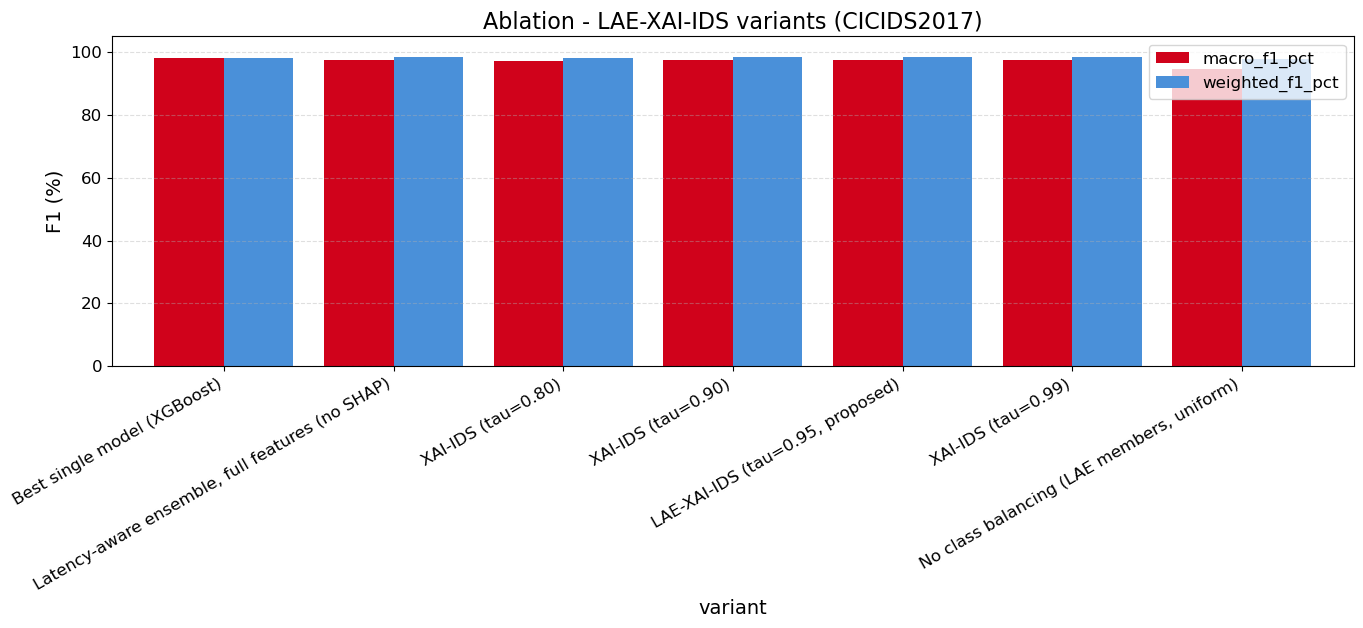

Saved plot data: CICIDS2017_ablation_plotdata.csv


,macro_f1_pct,weighted_f1_pct
variant,,
Best single model (XGBoost),98.256,98.227
"Latency-aware ensemble, full features (no SHAP)",97.499,98.384
XAI-IDS (tau=0.80),97.288,98.184
XAI-IDS (tau=0.90),97.439,98.313
"LAE-XAI-IDS (tau=0.95, proposed)",97.539,98.383
XAI-IDS (tau=0.99),97.478,98.341
"No class balancing (LAE members, uniform)",94.446,97.699


In [14]:
plot_df = ablation_df.set_index("variant")[["macro_f1_pct", "weighted_f1_pct"]]
fig, ax = plt.subplots(figsize=(14, 6.5))
plot_df.plot(kind="bar", ax=ax, color=["#D0021B", "#4A90D9"], width=0.82)
ax.set_ylabel("F1 (%)")
ax.set_ylim(0, 105)
ax.set_title(f"Ablation - LAE-XAI-IDS variants ({DATASET_TAG})")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
save_figure(fig, "ablation")
plt.show()
save_plot_data(plot_df.reset_index(), "ablation")
plot_df.round(3)


## Results comparison and visualizations

Every figure is saved as a PNG and its values as a `*_plotdata.csv`, so any plot can be rebuilt.


In [15]:
METHOD_ORDER = BASELINE_NAMES + [ENSEMBLE_NAME, PROPOSED_NAME]

final_table = pd.DataFrame({name: {
    "Accuracy (%)": results[name]["accuracy"] * 100,
    "Precision (%)": results[name]["precision"] * 100,
    "Recall (%)": results[name]["recall"] * 100,
    "Weighted F1 (%)": results[name]["weighted_f1"] * 100,
    "Macro F1 (%)": results[name]["macro_f1"] * 100,
    "Batch Latency (ms)": results[name]["batch_latency_ms"],
    "P99 Single-Row Latency (ms)": results[name]["p99_latency_ms"],
    "Model Size (MB)": results[name]["model_size_mb"],
} for name in METHOD_ORDER}).T

final_table.to_csv(f"{DATASET_TAG}_comparison_table.csv")
save_plot_data(final_table.reset_index().rename(columns={"index": "model"}), "comparison_table")
final_table.round(3)


Saved plot data: CICIDS2017_comparison_table_plotdata.csv


,Accuracy (%),Precision (%),Recall (%),Weighted F1 (%),Macro F1 (%),Batch Latency (ms),P99 Single-Row Latency (ms),Model Size (MB)
Decision Tree,97.925,97.963,97.925,97.920,97.930,0.000,1.607,0.130
Random Forest,98.192,98.242,98.192,98.186,98.236,0.084,71.793,46.245
XGBoost,98.234,98.269,98.234,98.227,98.256,0.004,5.847,5.120
LightGBM,98.332,98.362,98.332,98.328,97.436,0.018,3.799,16.043
CatBoost,98.374,98.395,98.374,98.371,96.490,0.001,2.082,6.285
SVM,91.953,92.086,91.953,91.444,83.849,0.367,1.640,3.137
Logistic Regression,93.691,94.485,93.691,93.907,82.433,0.001,0.871,0.007
AutoML-Ensemble,98.388,98.416,98.388,98.384,97.499,0.016,8.412,27.449
LAE-XAI-IDS,98.388,98.416,98.388,98.383,97.539,0.014,5.852,27.435


In [16]:
# Supplementary: full disjoint test (before any class cap).
if SCORE_FULL_TEST:
    print("Scoring fitted models on FULL disjoint test for the supplementary CSV ...")
    print(f"Skip on full test (slow): {FULLTEST_SKIP}")
    full_rows = {}
    for name in METHOD_ORDER:
        if name in FULLTEST_SKIP:
            print(f"  {name:22s}  skipped")
            continue
        model = fitted_models[name]
        X_te = X_test_full[selected_features] if name == PROPOSED_NAME else X_test_full
        y_pred_full = model.predict(X_te)
        acc = accuracy_score(y_test_full, y_pred_full)
        prec, rec, w_f1, _ = precision_recall_fscore_support(
            y_test_full, y_pred_full, average="weighted", zero_division=0)
        macro_f1 = f1_score(y_test_full, y_pred_full, average="macro", zero_division=0)
        full_rows[name] = {"Accuracy (%)": acc * 100, "Precision (%)": prec * 100,
                           "Recall (%)": rec * 100, "Weighted F1 (%)": w_f1 * 100,
                           "Macro F1 (%)": macro_f1 * 100,
                           "P99 Single-Row Latency (ms)": results[name]["p99_latency_ms"],
                           "Model Size (MB)": results[name]["model_size_mb"]}
        print(f"  {name:22s}  WF1={w_f1:.4f}  MacroF1={macro_f1:.4f}")
    full_table = pd.DataFrame(full_rows).T
    full_table.to_csv(f"{DATASET_TAG}_comparison_table_fulltest.csv")
    print("Saved", f"{DATASET_TAG}_comparison_table_fulltest.csv")
    _display = full_table.round(3)
else:
    print("SCORE_FULL_TEST=False - supplementary full-test table skipped.")
    _display = None
_display


Scoring fitted models on FULL disjoint test for the supplementary CSV ...
Skip on full test (slow): ('SVM', 'Logistic Regression')
  Decision Tree           WF1=0.9912  MacroF1=0.7068
  Random Forest           WF1=0.9953  MacroF1=0.8333
  XGBoost                 WF1=0.9949  MacroF1=0.7982
  LightGBM                WF1=0.9954  MacroF1=0.7722
  CatBoost                WF1=0.9898  MacroF1=0.6609
  SVM                     skipped
  Logistic Regression     skipped
  AutoML-Ensemble         WF1=0.9953  MacroF1=0.7667
  LAE-XAI-IDS             WF1=0.9951  MacroF1=0.7629
Saved CICIDS2017_comparison_table_fulltest.csv


,Accuracy (%),Precision (%),Recall (%),Weighted F1 (%),Macro F1 (%),P99 Single-Row Latency (ms),Model Size (MB)
Decision Tree,99.041,99.258,99.041,99.123,70.683,1.607,0.130
Random Forest,99.498,99.595,99.498,99.533,83.329,71.793,46.245
XGBoost,99.436,99.571,99.436,99.486,79.825,5.847,5.120
LightGBM,99.496,99.611,99.496,99.538,77.215,3.799,16.043
CatBoost,98.803,99.234,98.803,98.978,66.091,2.082,6.285
AutoML-Ensemble,99.484,99.607,99.484,99.529,76.672,8.412,27.449
LAE-XAI-IDS,99.465,99.589,99.465,99.510,76.287,5.852,27.435


Saved figure: CICIDS2017_performance_comparison.png


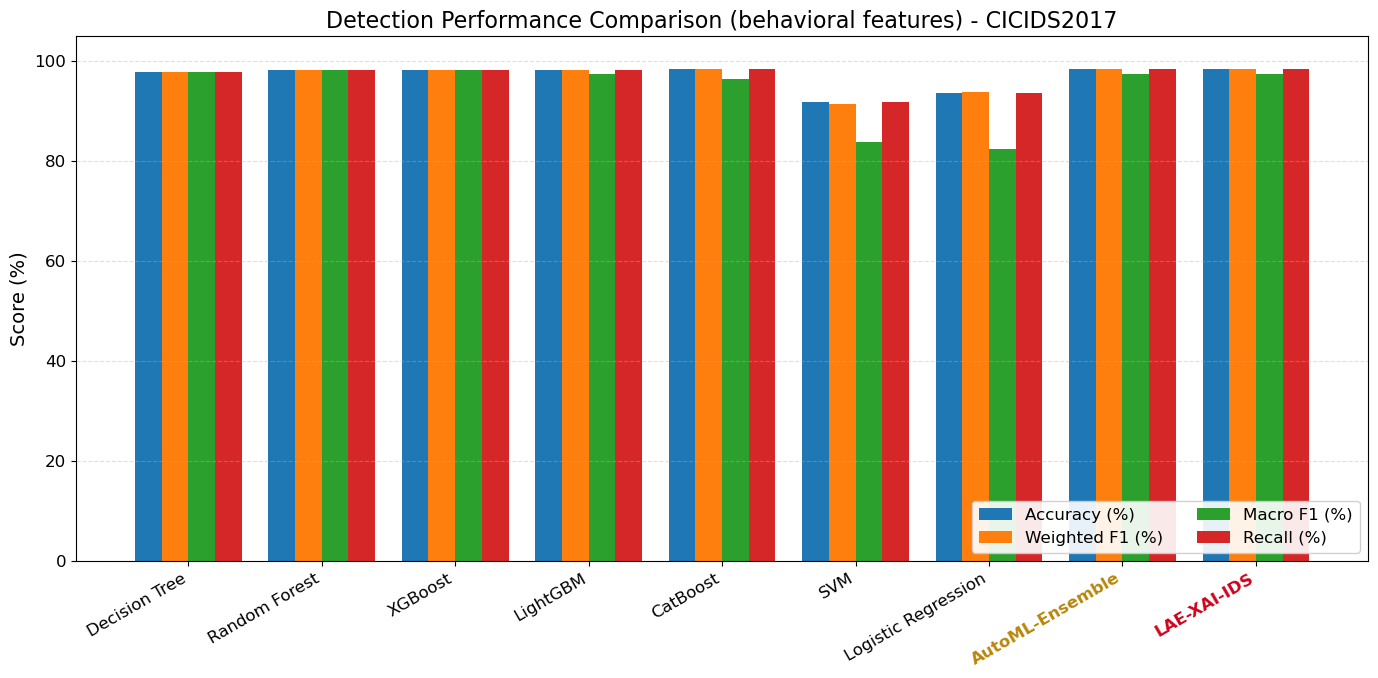

Saved plot data: CICIDS2017_performance_comparison_plotdata.csv


,Accuracy (%),Weighted F1 (%),Macro F1 (%),Recall (%)
Decision Tree,97.925,97.920,97.930,97.925
Random Forest,98.192,98.186,98.236,98.192
XGBoost,98.234,98.227,98.256,98.234
LightGBM,98.332,98.328,97.436,98.332
CatBoost,98.374,98.371,96.490,98.374
SVM,91.953,91.444,83.849,91.953
Logistic Regression,93.691,93.907,82.433,93.691
AutoML-Ensemble,98.388,98.384,97.499,98.388
LAE-XAI-IDS,98.388,98.383,97.539,98.388


In [17]:
PALETTE = sns.color_palette("Blues_d", n_colors=len(BASELINE_NAMES))
BAR_COLORS = {name: PALETTE[i] for i, name in enumerate(BASELINE_NAMES)}
BAR_COLORS[ENSEMBLE_NAME] = "#F5A623"
BAR_COLORS[PROPOSED_NAME] = "#D0021B"

metrics_to_plot = ["Accuracy (%)", "Weighted F1 (%)", "Macro F1 (%)", "Recall (%)"]
x = np.arange(len(METHOD_ORDER)); width = 0.2
fig, ax = plt.subplots(figsize=(14, 7))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + (i - 1.5) * width, final_table[metric].values, width, label=metric)
ax.set_xticks(x); ax.set_xticklabels(METHOD_ORDER, rotation=30, ha="right")
ax.set_ylabel("Score (%)"); ax.set_ylim(0, 105)
ax.set_title(f"Detection Performance Comparison (behavioral features) - {DATASET_TAG}")
ax.legend(loc="lower right", ncol=2, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
for lbl in ax.get_xticklabels():
    if lbl.get_text() == PROPOSED_NAME:
        lbl.set_color("#D0021B"); lbl.set_fontweight("bold")
    elif lbl.get_text() == ENSEMBLE_NAME:
        lbl.set_color("#B8860B"); lbl.set_fontweight("bold")
fig.tight_layout()
save_figure(fig, "performance_comparison")
plt.show()
save_plot_data(final_table[metrics_to_plot].reset_index().rename(columns={"index": "model"}),
               "performance_comparison")
final_table[metrics_to_plot].round(3)


Saved figure: CICIDS2017_per_class_f1.png


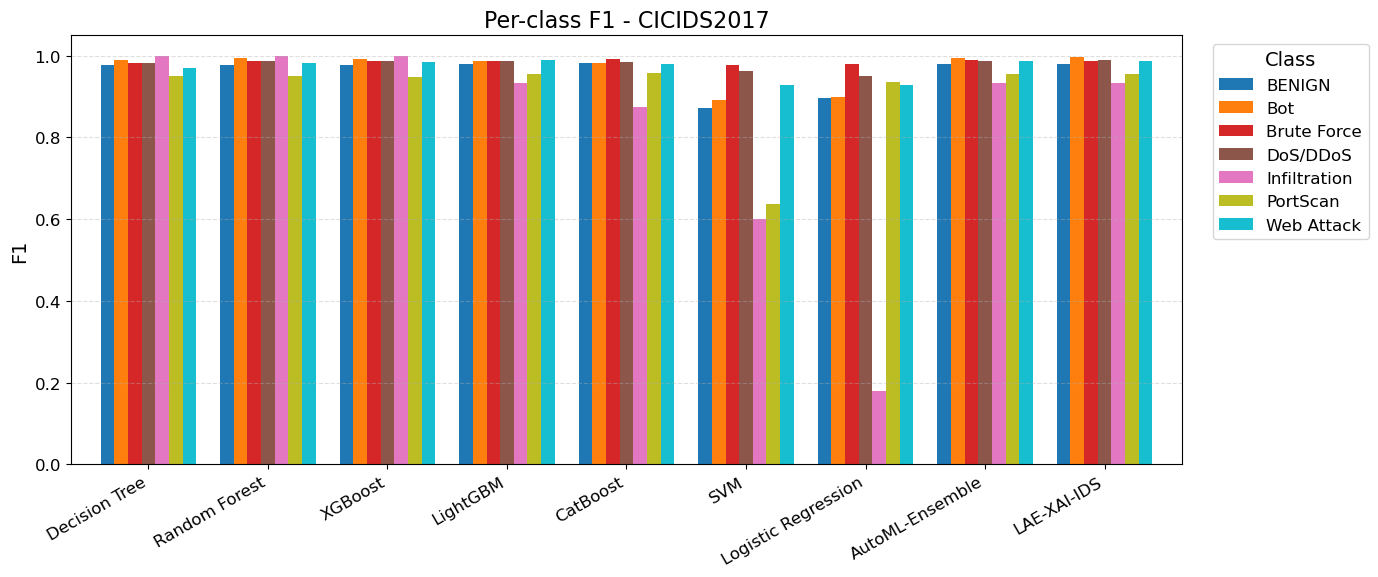

Saved plot data: CICIDS2017_per_class_f1_plotdata.csv


,Decision Tree,Random Forest,XGBoost,LightGBM,CatBoost,SVM,Logistic Regression,AutoML-Ensemble,LAE-XAI-IDS
class,,,,,,,,,
BENIGN,0.979,0.976,0.978,0.979,0.982,0.872,0.898,0.981,0.981
Bot,0.990,0.994,0.992,0.988,0.982,0.892,0.899,0.994,0.996
Brute Force,0.983,0.988,0.987,0.988,0.992,0.977,0.980,0.989,0.988
DoS/DDoS,0.983,0.988,0.988,0.988,0.985,0.963,0.951,0.988,0.989
Infiltration,1.000,1.000,1.000,0.933,0.875,0.600,0.179,0.933,0.933
PortScan,0.951,0.949,0.947,0.955,0.958,0.637,0.935,0.954,0.954
Web Attack,0.969,0.981,0.985,0.989,0.980,0.928,0.929,0.986,0.988


In [18]:
# Per-class F1 - the honest view under class imbalance.
per_class_f1 = {}
for name in METHOD_ORDER:
    per_class_f1[name] = f1_score(y_test, results[name]["y_pred"], average=None,
                                  zero_division=0, labels=list(classes_ref))

f1_df = pd.DataFrame(per_class_f1, index=class_names)
f1_df.index.name = "class"
f1_df.to_csv(f"{DATASET_TAG}_per_class_f1.csv")

fig, ax = plt.subplots(figsize=(14, 6))
f1_df.T.plot(kind="bar", ax=ax, width=0.8, colormap="tab10")
ax.set_ylabel("F1"); ax.set_ylim(0, 1.05)
ax.set_title(f"Per-class F1 - {DATASET_TAG}")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
save_figure(fig, "per_class_f1")
plt.show()
save_plot_data(f1_df.reset_index(), "per_class_f1")
f1_df.round(3)


Saved figure: CICIDS2017_efficiency_comparison.png


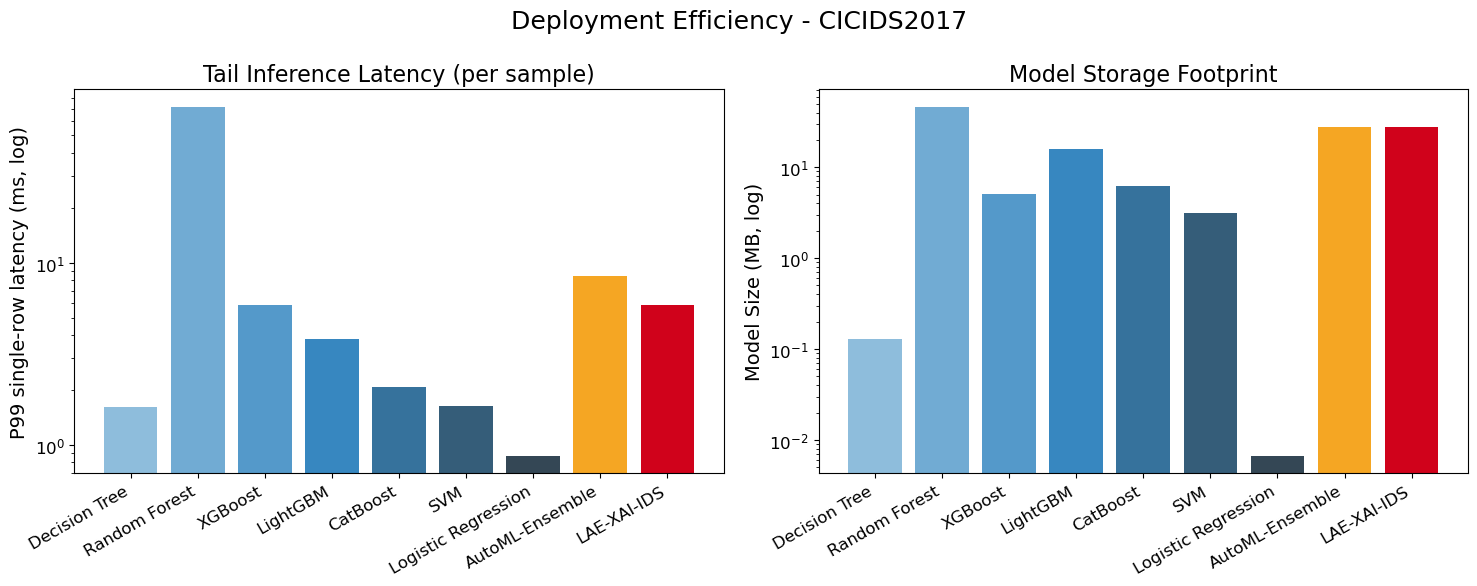

Saved plot data: CICIDS2017_efficiency_comparison_plotdata.csv


,model,P99 Single-Row Latency (ms),Model Size (MB)
0,Decision Tree,1.606924,0.130265
1,Random Forest,71.793454,46.244536
2,XGBoost,5.846556,5.120412
3,LightGBM,3.799333,16.042968
4,CatBoost,2.081946,6.285275
5,SVM,1.639553,3.136727
6,Logistic Regression,0.870605,0.006686
7,AutoML-Ensemble,8.411794,27.448727
8,LAE-XAI-IDS,5.851792,27.434855


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = [BAR_COLORS[n] for n in METHOD_ORDER]

axes[0].bar(METHOD_ORDER, final_table["P99 Single-Row Latency (ms)"], color=colors)
axes[0].set_yscale("log"); axes[0].set_ylabel("P99 single-row latency (ms, log)")
axes[0].set_title("Tail Inference Latency (per sample)")
axes[0].tick_params(axis="x", rotation=30)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

axes[1].bar(METHOD_ORDER, final_table["Model Size (MB)"], color=colors)
axes[1].set_yscale("log"); axes[1].set_ylabel("Model Size (MB, log)")
axes[1].set_title("Model Storage Footprint")
axes[1].tick_params(axis="x", rotation=30)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

fig.suptitle(f"Deployment Efficiency - {DATASET_TAG}")
fig.tight_layout()
save_figure(fig, "efficiency_comparison")
plt.show()
save_plot_data(final_table[["P99 Single-Row Latency (ms)", "Model Size (MB)"]]
               .reset_index().rename(columns={"index": "model"}), "efficiency_comparison")


Saved figure: CICIDS2017_tradeoff_scatter.png


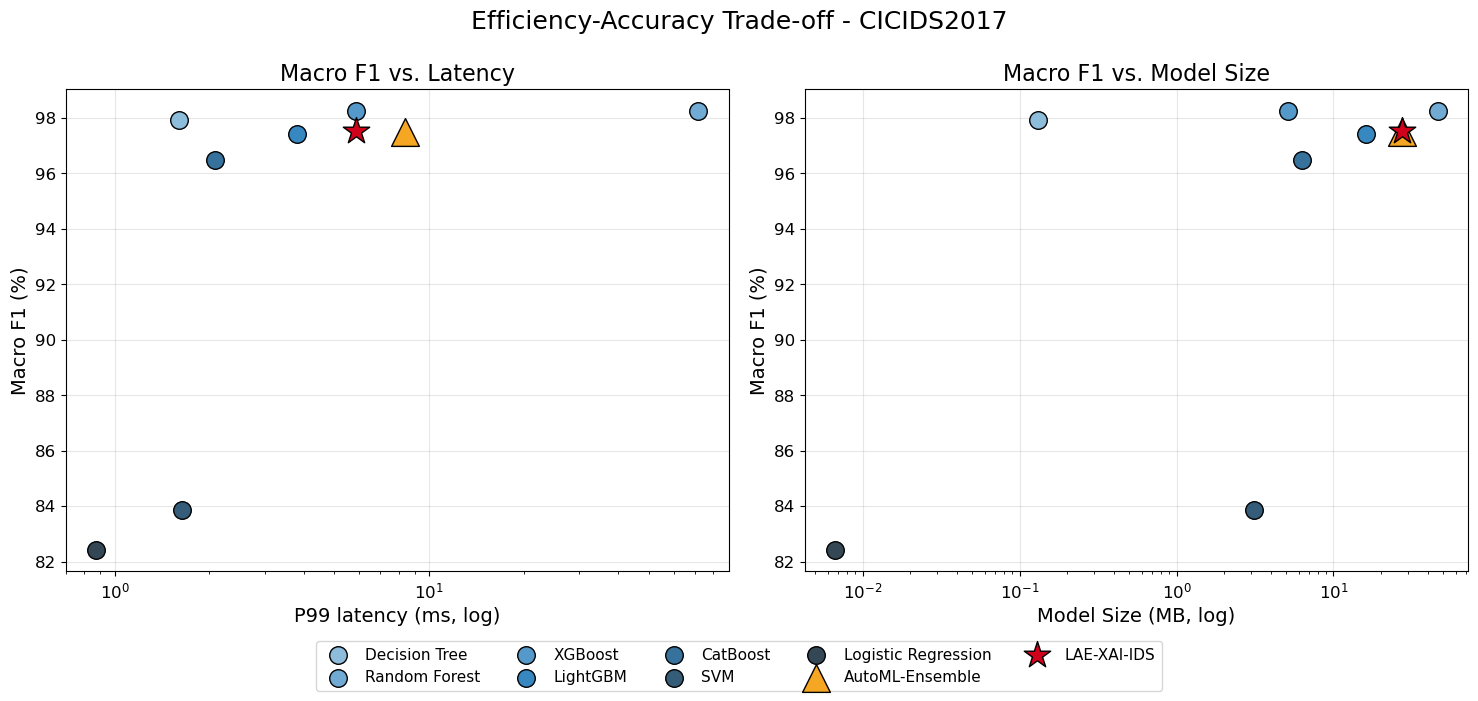

Saved plot data: CICIDS2017_tradeoff_scatter_plotdata.csv


,model,P99 Single-Row Latency (ms),Model Size (MB),Macro F1 (%)
0,Decision Tree,1.606924,0.130265,97.930490
1,Random Forest,71.793454,46.244536,98.236056
2,XGBoost,5.846556,5.120412,98.256136
3,LightGBM,3.799333,16.042968,97.435639
4,CatBoost,2.081946,6.285275,96.489580
5,SVM,1.639553,3.136727,83.849202
6,Logistic Regression,0.870605,0.006686,82.432827
7,AutoML-Ensemble,8.411794,27.448727,97.499299
8,LAE-XAI-IDS,5.851792,27.434855,97.538657


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for name in METHOD_ORDER:
    marker = "*" if name == PROPOSED_NAME else ("^" if name == ENSEMBLE_NAME else "o")
    s = 400 if name in (PROPOSED_NAME, ENSEMBLE_NAME) else 160
    axes[0].scatter(final_table.loc[name, "P99 Single-Row Latency (ms)"],
                    final_table.loc[name, "Macro F1 (%)"],
                    s=s, marker=marker, color=BAR_COLORS[name],
                    edgecolor="black", zorder=3, label=name)
    axes[1].scatter(final_table.loc[name, "Model Size (MB)"],
                    final_table.loc[name, "Macro F1 (%)"],
                    s=s, marker=marker, color=BAR_COLORS[name],
                    edgecolor="black", zorder=3, label=name)

axes[0].set_xscale("log"); axes[0].set_xlabel("P99 latency (ms, log)")
axes[0].set_ylabel("Macro F1 (%)"); axes[0].set_title("Macro F1 vs. Latency")
axes[0].grid(alpha=0.3)
axes[1].set_xscale("log"); axes[1].set_xlabel("Model Size (MB, log)")
axes[1].set_ylabel("Macro F1 (%)"); axes[1].set_title("Macro F1 vs. Model Size")
axes[1].grid(alpha=0.3)

h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.08), fontsize=11)
fig.suptitle(f"Efficiency-Accuracy Trade-off - {DATASET_TAG}")
fig.tight_layout()
save_figure(fig, "tradeoff_scatter")
plt.show()
save_plot_data(final_table[["P99 Single-Row Latency (ms)", "Model Size (MB)", "Macro F1 (%)"]]
               .reset_index().rename(columns={"index": "model"}), "tradeoff_scatter")


Saved figure: CICIDS2017_confusion_matrix_grid.png


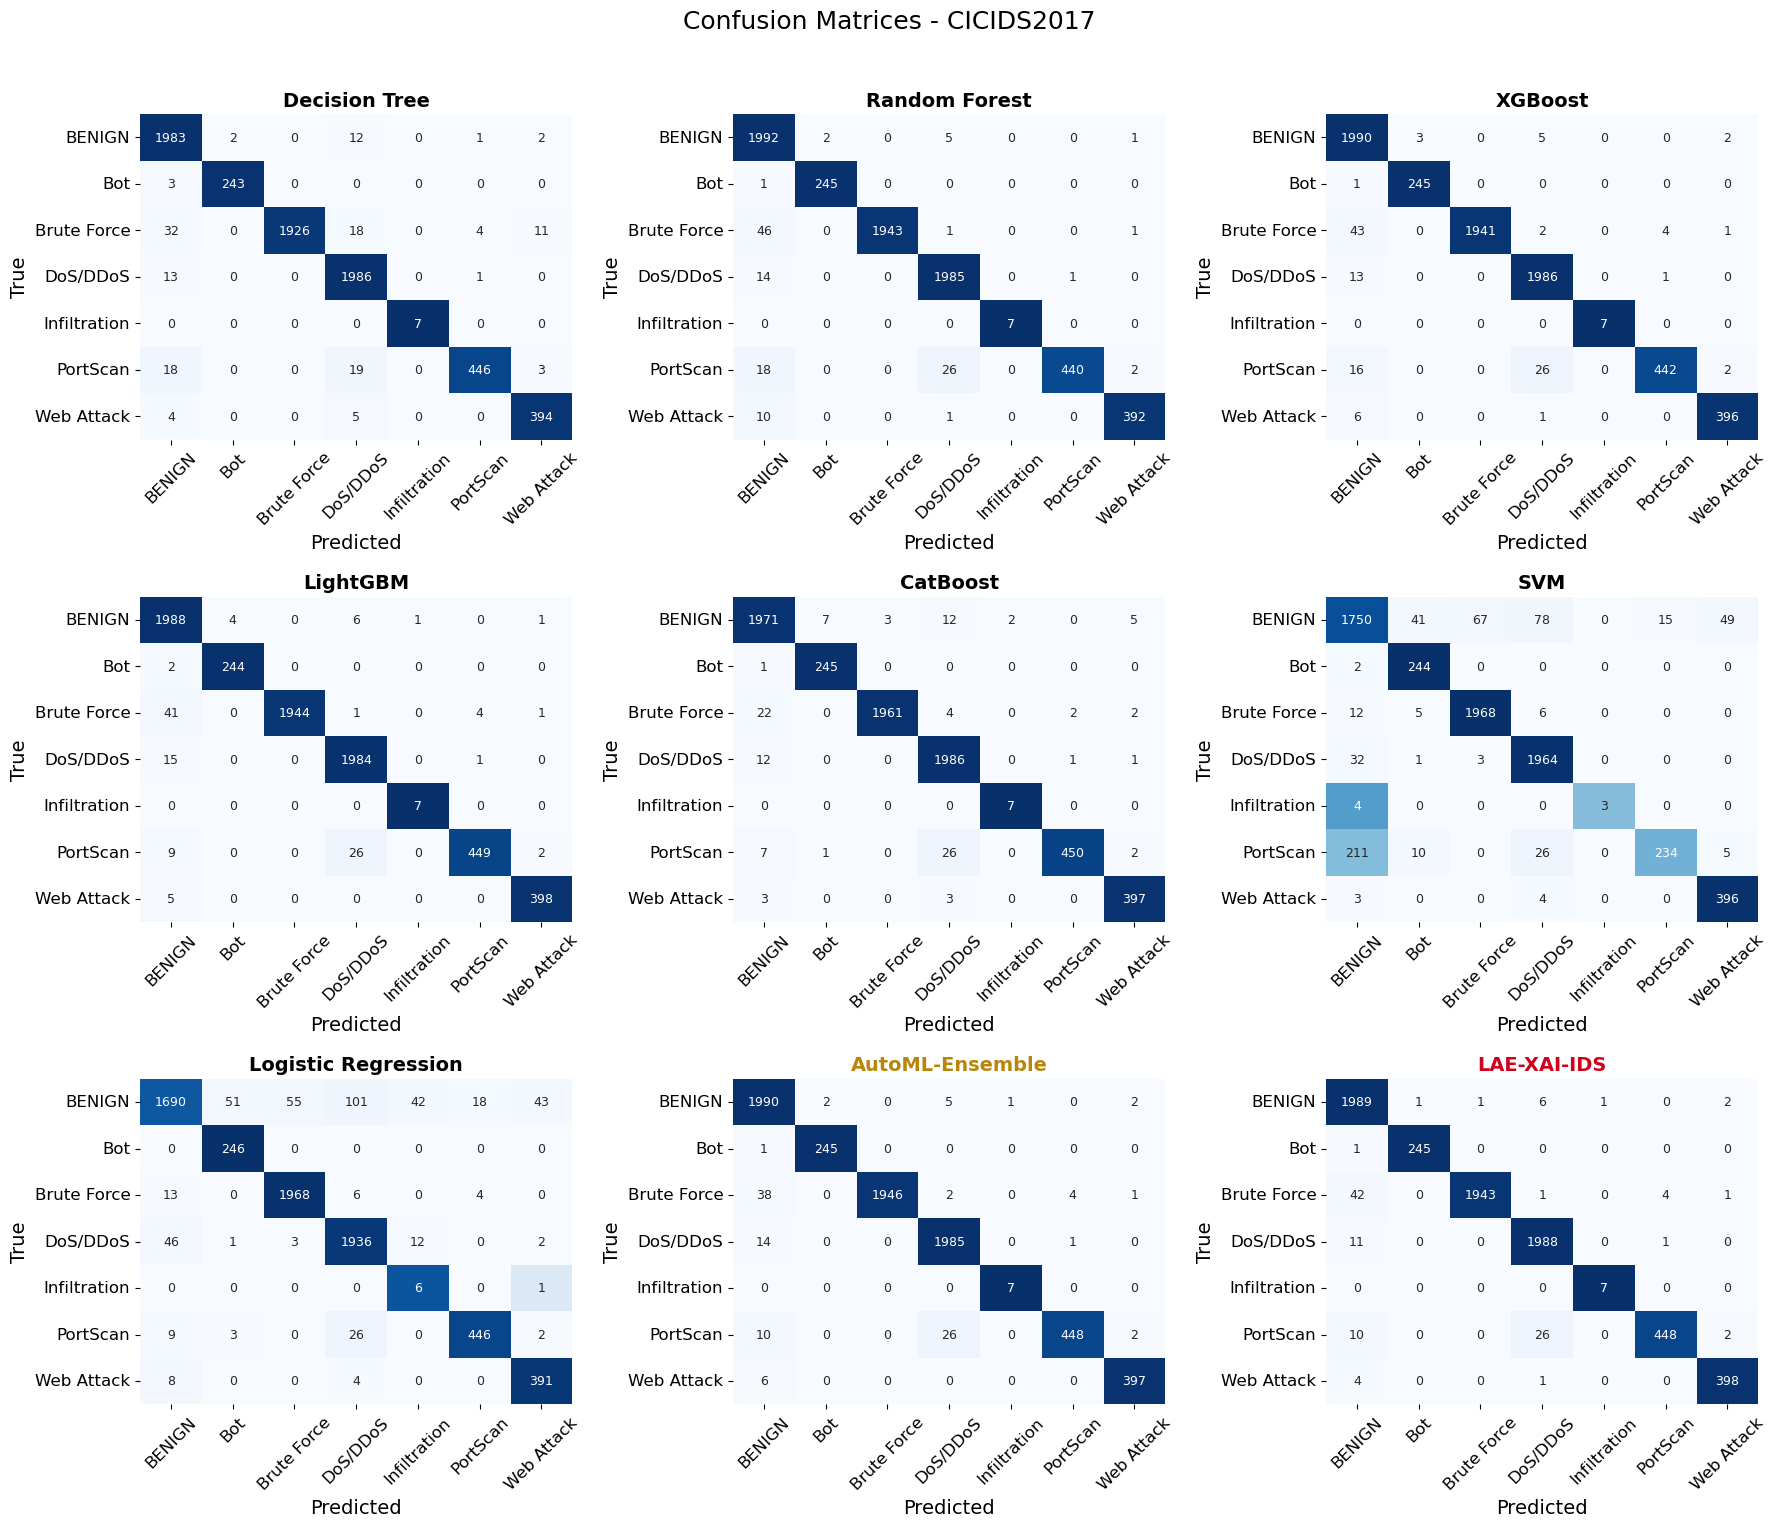

In [21]:
n_methods = len(METHOD_ORDER); n_cols = 3
n_rows = int(np.ceil(n_methods / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, name in enumerate(METHOD_ORDER):
    cm = results[name]["confusion_matrix"]
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    ax = axes[i]
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                annot_kws={"size": 9})
    tcolor = "#D0021B" if name == PROPOSED_NAME else ("#B8860B" if name == ENSEMBLE_NAME else "black")
    ax.set_title(name, fontsize=14, color=tcolor, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
for j in range(n_methods, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Confusion Matrices - {DATASET_TAG}", fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(fig, "confusion_matrix_grid")
plt.show()


Saved figure: CICIDS2017_proposed_confusion_matrix.png


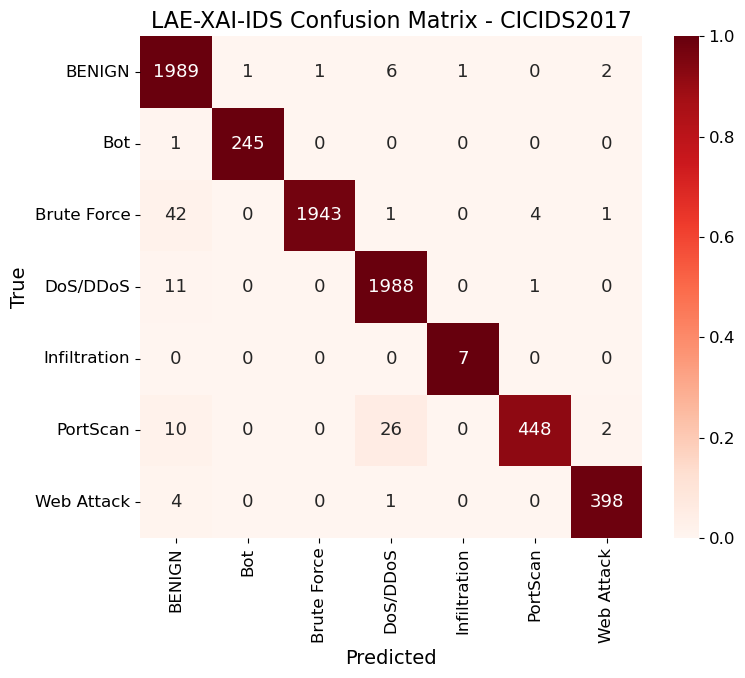

In [22]:
cm = results[PROPOSED_NAME]["confusion_matrix"]
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Reds", cbar=True,
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            annot_kws={"size": 13})
ax.set_title(f"{LAE_NAME} Confusion Matrix - {DATASET_TAG}", fontsize=16)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout()
save_figure(fig, "proposed_confusion_matrix")
plt.show()


Saved figure: CICIDS2017_shap_feature_importance.png


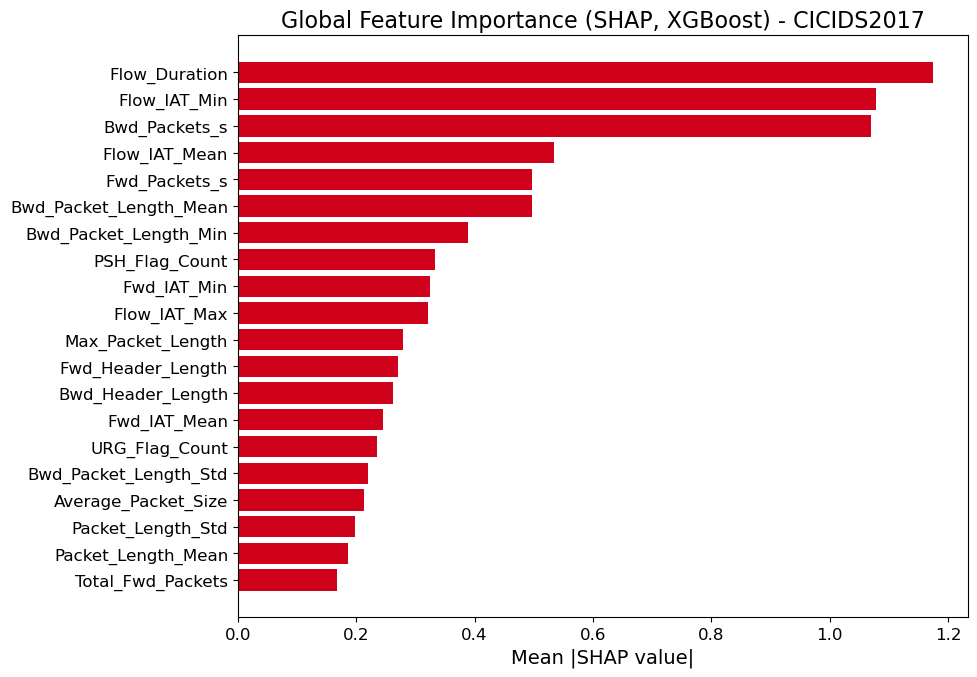

Saved plot data: CICIDS2017_shap_feature_importance_plotdata.csv
Saved figure: CICIDS2017_shap_cumulative_importance.png


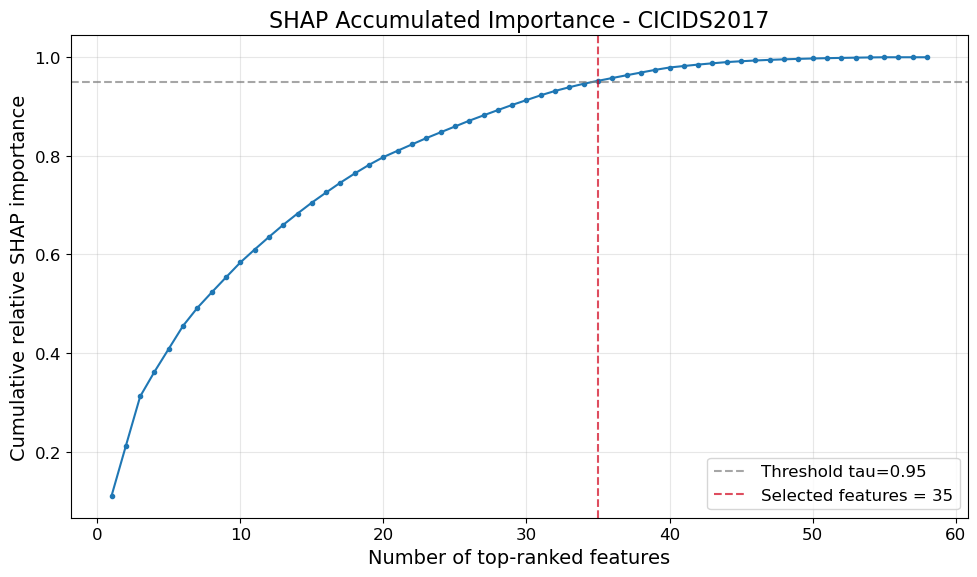

Saved plot data: CICIDS2017_shap_cumulative_importance_plotdata.csv


,feature,mean_abs_shap,relative_importance,cumulative_importance
0,Flow_Duration,1.1749,0.1103,0.1103
1,Flow_IAT_Min,1.0785,0.1012,0.2115
2,Bwd_Packets_s,1.0690,0.1003,0.3119
3,Flow_IAT_Mean,0.5338,0.0501,0.3620
4,Fwd_Packets_s,0.4970,0.0467,0.4086
5,Bwd_Packet_Length_Mean,0.4962,0.0466,0.4552
6,Bwd_Packet_Length_Min,0.3882,0.0364,0.4917
7,PSH_Flag_Count,0.3336,0.0313,0.5230
8,Fwd_IAT_Min,0.3255,0.0306,0.5535
9,Flow_IAT_Max,0.3210,0.0301,0.5837


In [23]:
# ---- SHAP global importance + cumulative importance ----
top_n = min(20, len(shap_importance_df))
plot_df = shap_importance_df.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
bar_colors = ["#D0021B" if f in selected_features else "#4A90D9" for f in plot_df["feature"]]
ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color=bar_colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Global Feature Importance (SHAP, {best_tree_name}) - {DATASET_TAG}")
fig.tight_layout()
save_figure(fig, "shap_feature_importance")
plt.show()
save_plot_data(plot_df.assign(selected=[f in selected_features for f in plot_df["feature"]]),
               "shap_feature_importance")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(shap_importance_df) + 1),
        shap_importance_df["cumulative_importance"], marker="o", markersize=3)
ax.axhline(SHAP_CUM_THRESHOLD, color="gray", linestyle="--", alpha=0.7,
           label=f"Threshold tau={SHAP_CUM_THRESHOLD}")
ax.axvline(len(selected_features), color="#D0021B", linestyle="--", alpha=0.7,
           label=f"Selected features = {len(selected_features)}")
ax.set_xlabel("Number of top-ranked features")
ax.set_ylabel("Cumulative relative SHAP importance")
ax.set_title(f"SHAP Accumulated Importance - {DATASET_TAG}")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, "shap_cumulative_importance")
plt.show()
save_plot_data(shap_importance_df, "shap_cumulative_importance")
shap_importance_df.head(15).round(4)


Saved figure: CICIDS2017_shap_summary_bar.png


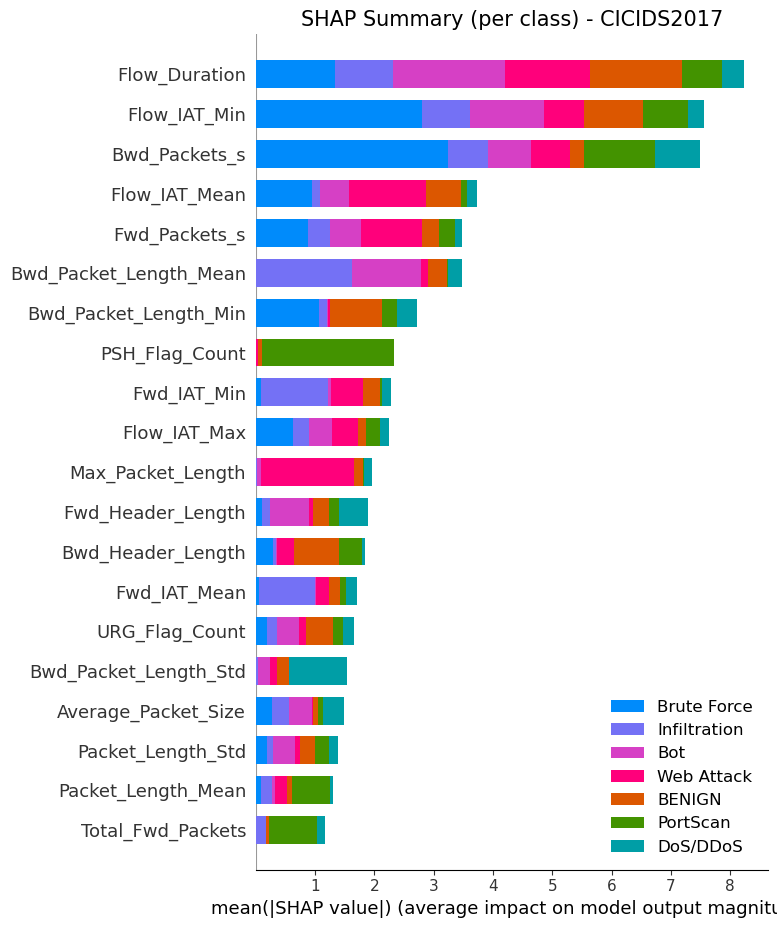

Saved plot data: CICIDS2017_shap_summary_plotdata.csv
Saved figure: CICIDS2017_shap_beeswarm_class0.png


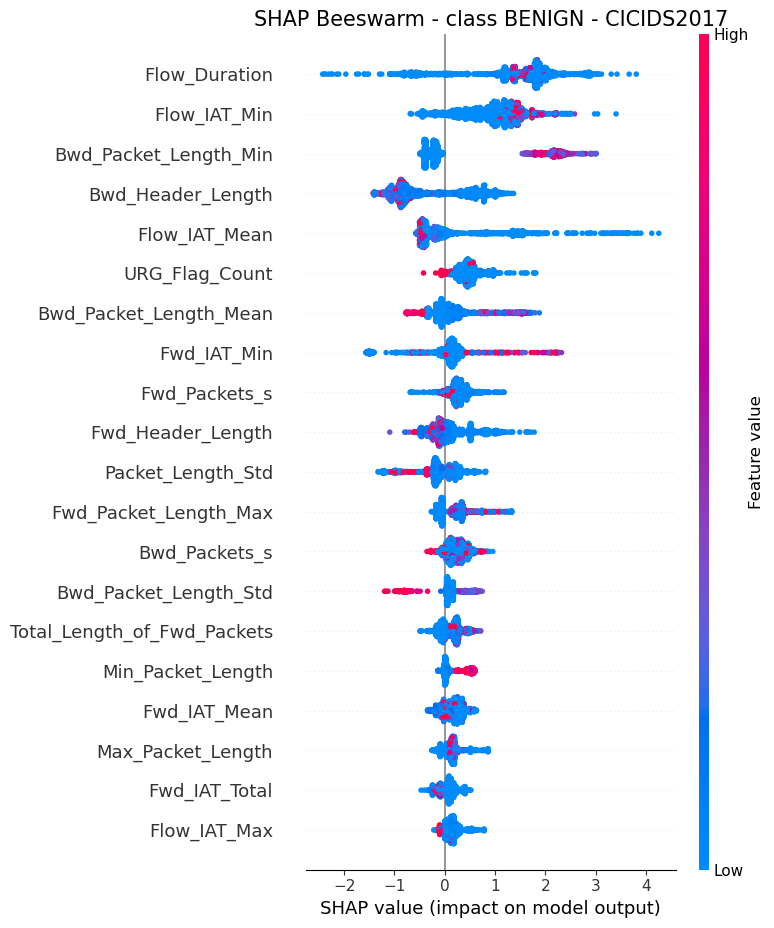

Saved plot data: CICIDS2017_shap_beeswarm_class0_plotdata.csv


,feature,shap_value,feature_value
0,Flow_Duration,0.661411,-0.439345
1,Flow_Duration,-0.184312,-0.439346
2,Flow_Duration,1.066704,-0.439160
3,Flow_Duration,1.114828,-0.439345
4,Flow_Duration,1.872853,-0.433576
...,...,...,...
23995,Fwd_Header_Length,0.515462,0.001236
23996,Fwd_Header_Length,-0.067644,0.001247
23997,Fwd_Header_Length,-0.232053,0.001242
23998,Fwd_Header_Length,-0.115528,0.001261


In [24]:
# ---- SHAP per-class summary + majority-class beeswarm ----
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar",
                  class_names=[str(c) for c in class_names], show=False)
plt.title(f"SHAP Summary (per class) - {DATASET_TAG}", fontsize=15)
plt.tight_layout()
save_figure(fig, "shap_summary_bar")
plt.show()
save_plot_data(summary_matrix.reset_index(), "shap_summary")

majority_class = int(pd.Series(y_train_arr).value_counts().idxmax())
class_pos = list(classes_ref).index(majority_class)
sv = sv_all[:, :, class_pos]

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(sv, shap_sample, show=False)
plt.title(f"SHAP Beeswarm - class {class_names[class_pos]} - {DATASET_TAG}", fontsize=15)
plt.tight_layout()
save_figure(fig, f"shap_beeswarm_class{classes_ref[class_pos]}")
plt.show()

_bees_feats = [f for f in shap_importance_df["feature"].head(12) if f in shap_sample.columns]
_feat_idx = [list(shap_sample.columns).index(f) for f in _bees_feats]
save_plot_data(pd.DataFrame({
    "feature": np.repeat(_bees_feats, len(shap_sample)),
    "shap_value": sv[:, _feat_idx].T.reshape(-1),
    "feature_value": shap_sample[_bees_feats].values.T.reshape(-1),
}), f"shap_beeswarm_class{classes_ref[class_pos]}")


Saved figure: CICIDS2017_shap_beeswarm_class0.png


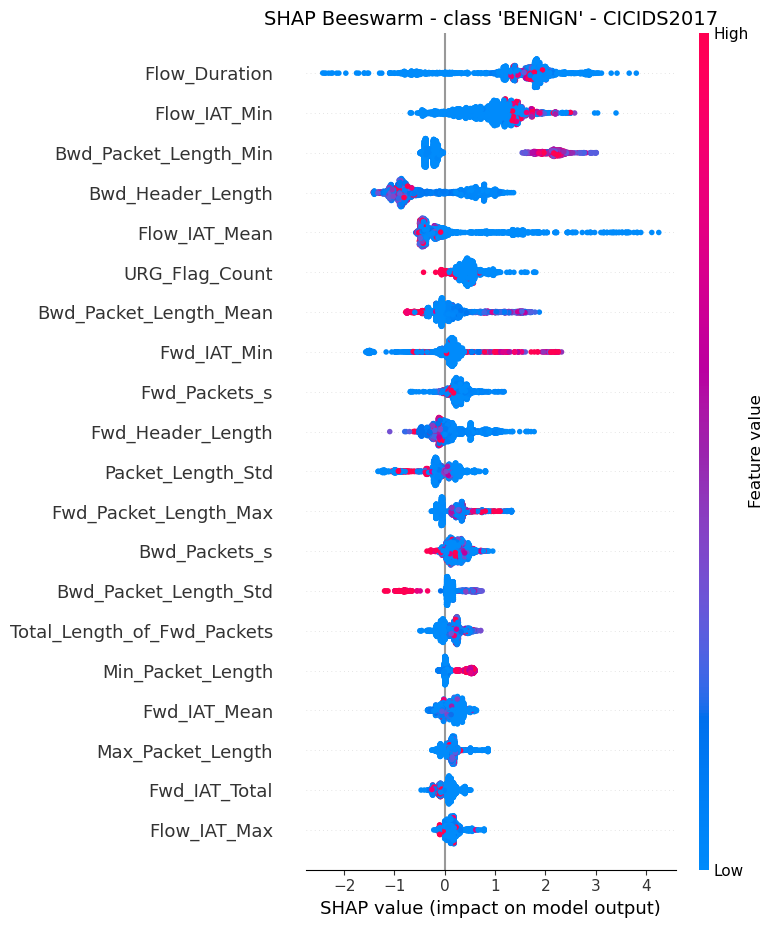

Saved figure: CICIDS2017_shap_beeswarm_class1.png


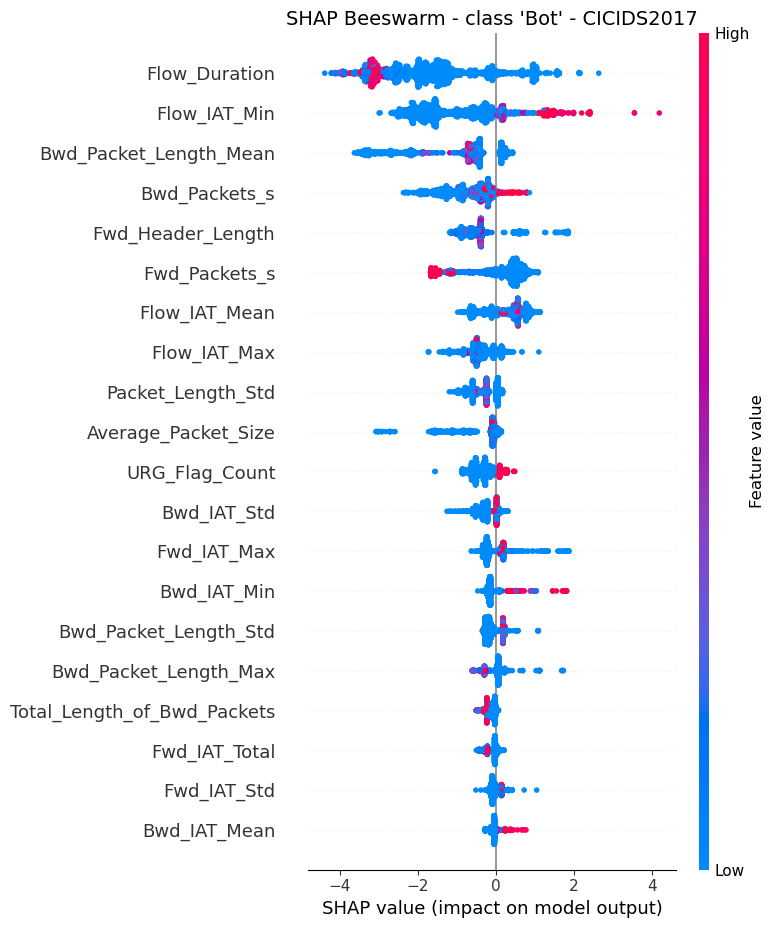

Saved figure: CICIDS2017_shap_beeswarm_class2.png


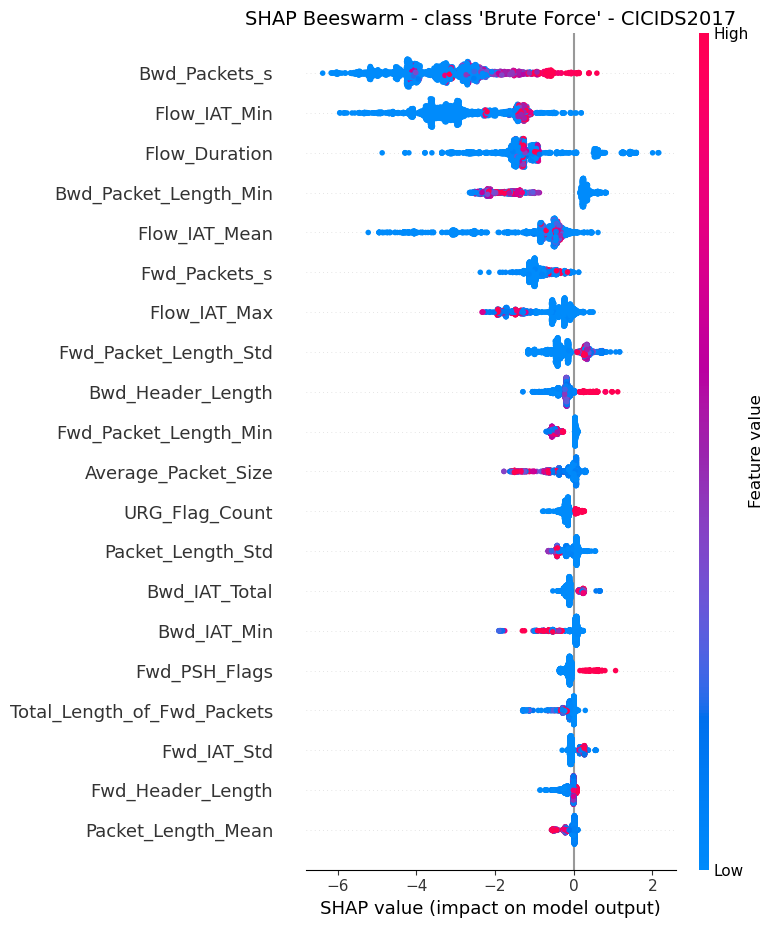

Saved figure: CICIDS2017_shap_beeswarm_class3.png


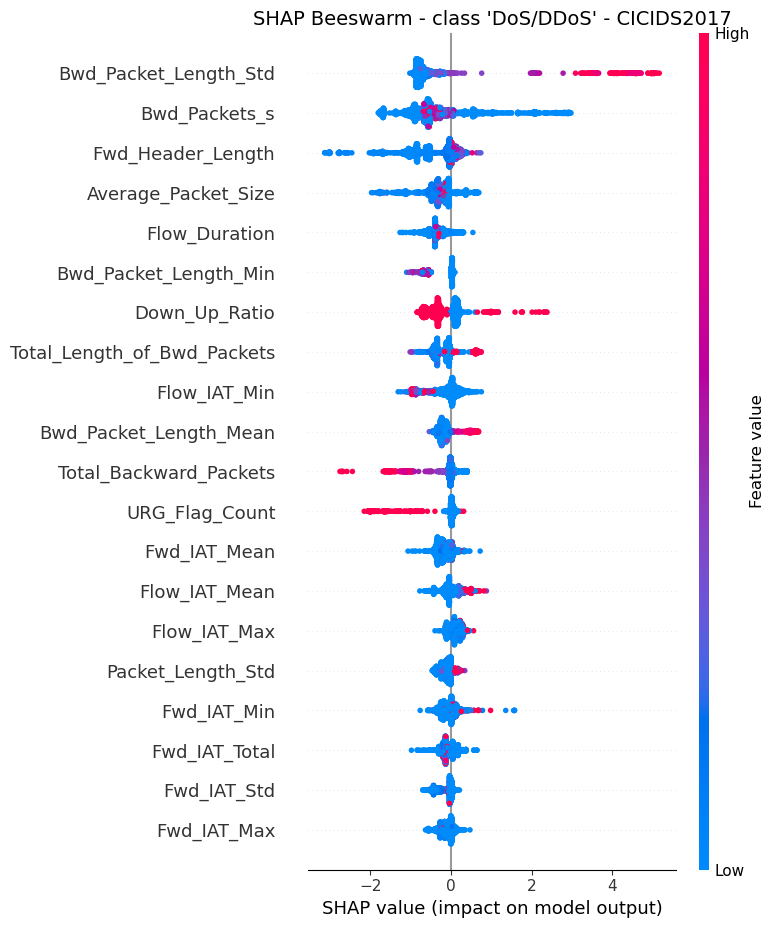

Saved figure: CICIDS2017_shap_beeswarm_class4.png


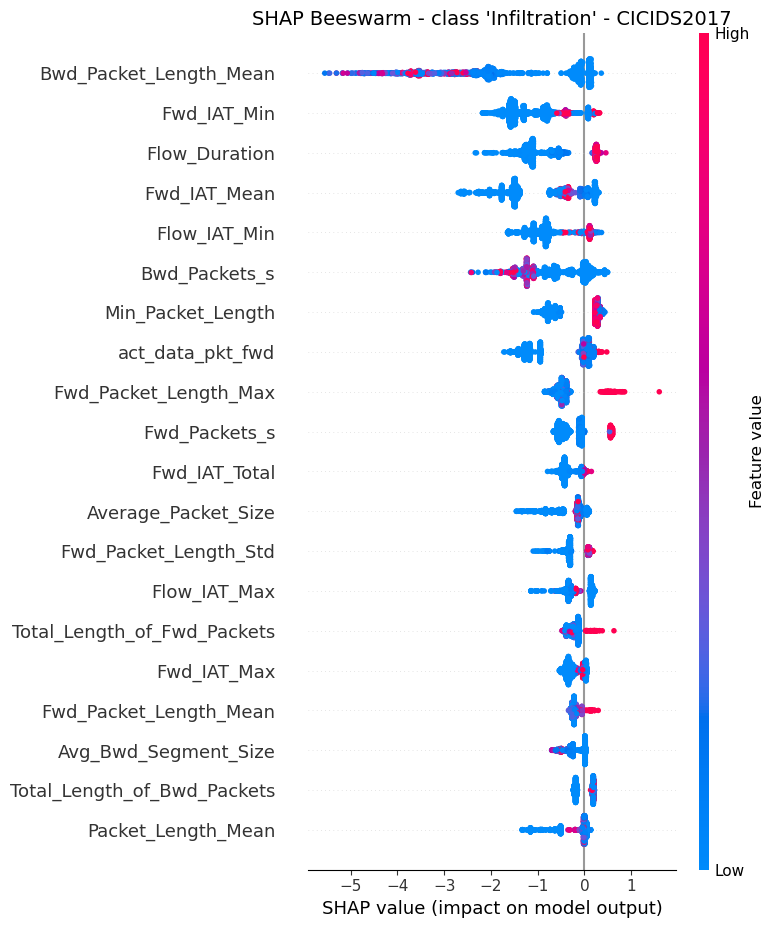

Saved figure: CICIDS2017_shap_beeswarm_class5.png


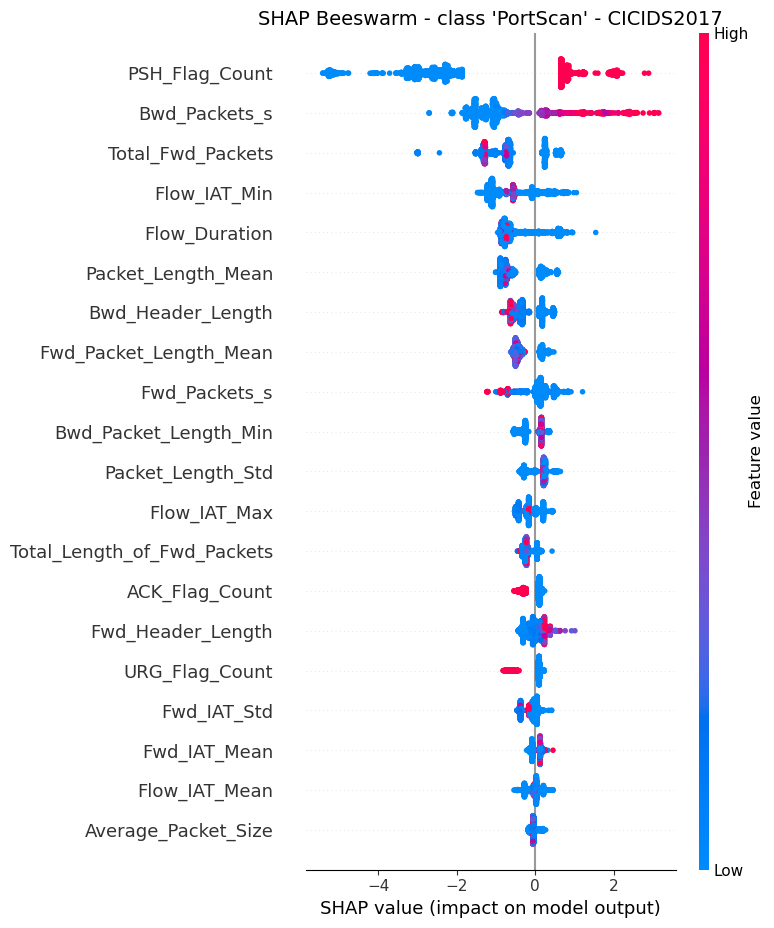

Saved figure: CICIDS2017_shap_beeswarm_class6.png


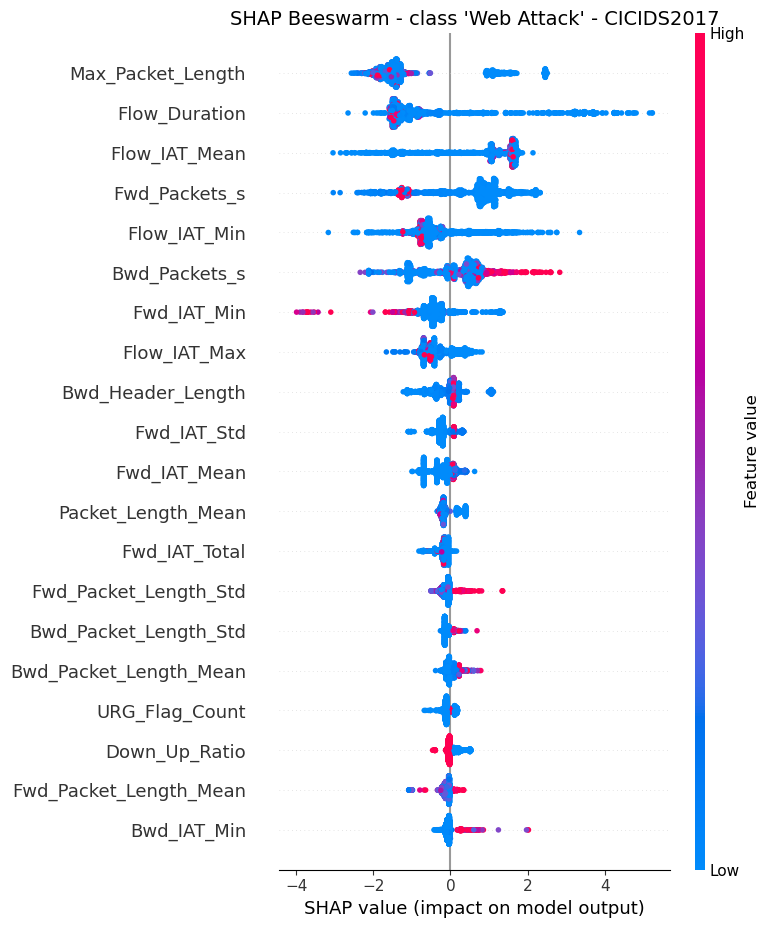

In [25]:
# ---- SHAP beeswarm per class ----
for c in range(len(classes_ref)):
    fig = plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_all[:, :, c], shap_sample, show=False)
    plt.title(f"SHAP Beeswarm - class '{class_names[c]}' - {DATASET_TAG}", fontsize=14)
    plt.tight_layout()
    save_figure(fig, f"shap_beeswarm_class{classes_ref[c]}")
    plt.show()


Saved figure: CICIDS2017_shap_waterfall_sample0.png


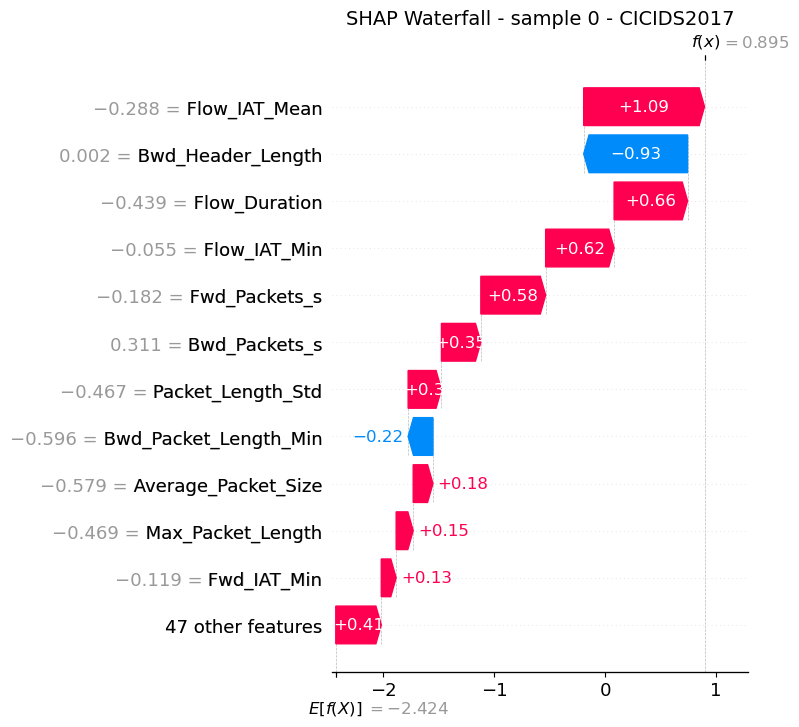

Saved plot data: CICIDS2017_shap_waterfall_sample0_plotdata.csv


,feature,shap_value,feature_value
30,Bwd_Header_Length,-0.934955,0.001587
10,Bwd_Packet_Length_Min,-0.223270,-0.596108
11,Bwd_Packet_Length_Mean,-0.067443,-0.505487
5,Fwd_Packet_Length_Max,-0.050132,-0.289465
49,act_data_pkt_fwd,-0.038262,-0.008514
20,Fwd_IAT_Max,-0.035948,-0.368661
6,Fwd_Packet_Length_Min,-0.032483,-0.310140
3,Total_Length_of_Fwd_Packets,-0.031061,-0.054965
29,Fwd_Header_Length,-0.027027,0.001236
2,Total_Backward_Packets,-0.021501,-0.009418


In [26]:
# ---- SHAP waterfall for one sample ----
one_idx = 0  # change this index to inspect other samples

base_val = explainer.expected_value
if isinstance(base_val, (list, tuple, np.ndarray)):
    base_val = float(np.asarray(base_val).reshape(-1)[0])
else:
    base_val = float(base_val)

explanation = shap.Explanation(
    values=np.asarray(sv_all[one_idx, :, 0]).reshape(-1),
    base_values=base_val,
    data=np.asarray(shap_sample.iloc[one_idx].values).reshape(-1),
    feature_names=list(shap_sample.columns),
)
fig = plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f"SHAP Waterfall - sample {one_idx} - {DATASET_TAG}", fontsize=14)
plt.tight_layout()
save_figure(fig, f"shap_waterfall_sample{one_idx}")
plt.show()
save_plot_data(pd.DataFrame({
    "feature": list(shap_sample.columns),
    "shap_value": np.asarray(explanation.values).reshape(-1),
    "feature_value": np.asarray(explanation.data).reshape(-1),
}).sort_values("shap_value"), f"shap_waterfall_sample{one_idx}")


In [27]:
print(classification_report(y_test, results[PROPOSED_NAME]["y_pred"],
                            target_names=class_names, zero_division=0))

print("=" * 70)
print("METHODOLOGY NOTES")
print("=" * 70)
print(f"1. Identifier/timestamp features removed for ALL models: {SUSPECT_FEATURES}")
print(f"2. Constant/duplicate columns dropped: {drop_extra}")
print(f"3. Flow-level train/test duplicate overlap: {overlap_pct:.2f}% of unique test")
print(f"   Overlapping test copies removed: {n_overlap_rows} rows")
print(f"4. Depth-3 probe RAW={raw_probe_acc*100:.2f}%  CLEAN={probe_acc*100:.2f}%")
print(f"5. Latency cap for ensemble members: {ENSEMBLE_LATENCY_CAP_MS} ms p99")
print("6. Class-balanced training: DT/RF/LGBM/SVM/LR class_weight=balanced,")
print("   CatBoost auto_class_weights=Balanced, XGBoost inverse-frequency sample weights.")
print(f"7. RUN_OPTUNA={RUN_OPTUNA}  trials={N_TRIALS_BASELINE} (SVM {N_TRIALS_SLOW}).")
print(f"8. Proposed model: {LAE_FULL_NAME} ({LAE_NAME}).")
print(f"9. SHAP representative tree chosen by Macro F1: {best_tree_name}.")
print(f"10. Tau sweep ablation: {ABLATION_TAUS}. SHAP summary matrix saved for cross-dataset plots.")
print("11. The ~80% BENIGN test split is why the headline table uses the class-capped split.")
print("12. Full disjoint-test metrics: CICIDS2017_comparison_table_fulltest.csv")


              precision    recall  f1-score   support

      BENIGN       0.97      0.99      0.98      2000
         Bot       1.00      1.00      1.00       246
 Brute Force       1.00      0.98      0.99      1991
    DoS/DDoS       0.98      0.99      0.99      2000
Infiltration       0.88      1.00      0.93         7
    PortScan       0.99      0.92      0.95       486
  Web Attack       0.99      0.99      0.99       403

    accuracy                           0.98      7133
   macro avg       0.97      0.98      0.98      7133
weighted avg       0.98      0.98      0.98      7133

METHODOLOGY NOTES
1. Identifier/timestamp features removed for ALL models: ['Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward']
2. Constant/duplicate columns dropped: ['Flow_Bytes_s', 'Flow_Packets_s', 'Bwd_PSH_Flags', 'Bwd_URG_Flags', 'Fwd_Avg_Bytes_Bulk', 'Fwd_Avg_Packets_Bulk', 'Fwd_Avg_Bulk_Rate', 'Bwd_Avg_Bytes_Bulk', 'Bwd_Avg_Packets_Bulk', 'Bwd_Avg_Bulk_Rate', 'Flow_Pa

In [28]:
# ============================================================
# Export CSVs / JSON
# ============================================================
test_counts = pd.Series(y_test).value_counts().sort_index()
train_dist = pd.DataFrame({
    "class_index": [int(c) for c in class_counts.sort_index().index],
    "class_name": [class_names[i] if i < len(class_names) else str(i)
                   for i in range(len(class_counts.sort_index()))],
    "n_train_full": class_counts.sort_index().values,
    "n_train_sampled": [int((y_train == i).sum()) for i in class_counts.sort_index().index],
    "n_test_eval": [int(test_counts.get(i, 0)) for i in class_counts.sort_index().index],
    "n_test_full_disjoint": [int((pd.Series(y_test_full) == i).sum())
                             for i in class_counts.sort_index().index],
})
train_dist.to_csv(f"{DATASET_TAG}_train_class_distribution.csv", index=False)

report_dict = classification_report(y_test, results[PROPOSED_NAME]["y_pred"],
                                    target_names=class_names, zero_division=0, output_dict=True)
pd.DataFrame(report_dict).T.to_csv(f"{DATASET_TAG}_per_class_report.csv")

run_config = {
    "dataset": DATASET_TAG,
    "proposed_model": LAE_NAME,
    "proposed_model_full_name": LAE_FULL_NAME,
    "train_csv": TRAIN_CSV,
    "test_csv": TEST_CSV,
    "RANDOM_STATE": RANDOM_STATE,
    "N_SPLITS_CV": N_SPLITS_CV,
    "SHAP_CUM_THRESHOLD": SHAP_CUM_THRESHOLD,
    "LATENCY_REPEATS": LATENCY_REPEATS,
    "LATENCY_ROWS": LATENCY_ROWS,
    "SVM_MAX_TRAIN_SAMPLES": SVM_MAX_TRAIN_SAMPLES,
    "ENSEMBLE_LATENCY_CAP_MS": ENSEMBLE_LATENCY_CAP_MS,
    "TOP_K": TOP_K,
    "RUN_OPTUNA": RUN_OPTUNA,
    "N_TRIALS_BASELINE": N_TRIALS_BASELINE,
    "ABLATION_TAUS": ABLATION_TAUS,
    "EVAL_MAX_PER_CLASS": EVAL_MAX_PER_CLASS,
    "n_test_full_disjoint": int(len(X_test_full)),
    "n_test_eval": int(len(X_test)),
    "SUSPECT_FEATURES": SUSPECT_FEATURES,
    "n_features_before": int(X_train_raw.shape[1]),
    "n_features_after": int(X_train.shape[1]),
    "n_selected_features": len(selected_features),
    "selected_features": selected_features,
    "class_mapping": {int(k): v for k, v in enumerate(class_names)},
    "sampling_rule": "keep all if count<10000 else int(count*0.02) per class",
    "best_tree_for_shap": best_tree_name,
    "ensemble_members": top_names,
    "ensemble_type": ensemble_type,
    "constant_or_duplicate_cols_dropped": drop_extra,
    "n_overlap_test_rows_removed": int(n_overlap_rows),
}
with open(f"{DATASET_TAG}_run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)


def _json_safe_metrics(name):
    r = results[name]
    out = {"accuracy": float(r["accuracy"]), "precision": float(r["precision"]),
           "recall": float(r["recall"]), "weighted_f1": float(r["weighted_f1"]),
           "macro_f1": float(r["macro_f1"]), "batch_latency_ms": float(r["batch_latency_ms"]),
           "p99_latency_ms": float(r["p99_latency_ms"]), "model_size_mb": float(r["model_size_mb"]),
           "train_time_s": float(train_times.get(name, np.nan)) if name in train_times else None,
           "n_features_used": int(X_train.shape[1] if name != PROPOSED_NAME else len(selected_features))}
    if name in (ENSEMBLE_NAME, PROPOSED_NAME):
        out["ensemble_members"] = top_names
        out["ensemble_type"] = ensemble_type
        out["oof_f1"] = float(r.get("oof_weighted_f1", ensemble_oof_f1))
    return out


results_dump = {
    "models": {name: _json_safe_metrics(name) for name in METHOD_ORDER},
    "diagnostics": {
        "duplicate_overlap_pct": float(overlap_pct),
        "n_overlap_test_rows_removed": int(n_overlap_rows),
        "depth3_probe_acc_raw": float(raw_probe_acc),
        "depth3_probe_acc_clean": float(probe_acc),
        "leakage_flagged": bool(LEAKAGE_SUSPECTED),
        "suspect_features": SUSPECT_FEATURES,
        "constant_or_duplicate_cols_dropped": drop_extra,
    },
}
with open(f"{DATASET_TAG}_results.json", "w") as f:
    json.dump(results_dump, f, indent=2)

print("Saved comparison / SHAP / ablation / config artifacts with prefix", DATASET_TAG)


Saved comparison / SHAP / ablation / config artifacts with prefix CICIDS2017


In [29]:
# ============================================================
# Save all confusion matrices for later custom plotting
# ============================================================
CM_DIR = f"{DATASET_TAG}_confusion_matrices"
os.makedirs(CM_DIR, exist_ok=True)

class_labels = list(class_names)
pd.DataFrame({"class_index": range(len(class_labels)), "class_name": class_labels}
             ).to_csv(os.path.join(CM_DIR, f"{DATASET_TAG}_class_labels.csv"), index=False)

for name in METHOD_ORDER:
    cm = np.asarray(results[name]["confusion_matrix"])
    cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
    cm_df.index.name = "True"
    cm_df.columns.name = "Predicted"
    safe_name = name.replace(" ", "_").replace("-", "_")
    cm_df.to_csv(os.path.join(CM_DIR, f"{DATASET_TAG}_{safe_name}_confusion_matrix.csv"))
    print(f"Saved: {name}")

print("\nAll confusion matrices saved.")
print(f"Folder: {CM_DIR}")


Saved: Decision Tree
Saved: Random Forest
Saved: XGBoost
Saved: LightGBM
Saved: CatBoost
Saved: SVM
Saved: Logistic Regression
Saved: AutoML-Ensemble
Saved: LAE-XAI-IDS

All confusion matrices saved.
Folder: CICIDS2017_confusion_matrices


## Cross-dataset SHAP comparison

Run this after **both** notebooks have produced their SHAP CSVs. It builds `(a) CICEVSE2024` and
`(b) CICIDS2017` side-by-side panels for three SHAP analyses only: global feature importance,
per-class summary, and cumulative importance. Beeswarm is intentionally excluded.


In [30]:
# ============================================================
# Combined SHAP panels: (a) CICEVSE2024  (b) CICIDS2017
# Only 3 analyses: feature importance, per-class summary, cumulative importance.
# ============================================================
TAG_A, TAG_B = "CICEVSE2024", "CICIDS2017"
COMBINED_PREFIX = "CROSS_DATASET"


def _load_csv(path):
    return pd.read_csv(path) if os.path.exists(path) else None


imp_a = _load_csv(f"{TAG_A}_shap_importance.csv")
imp_b = _load_csv(f"{TAG_B}_shap_importance.csv")
sum_a = _load_csv(f"{TAG_A}_shap_summary_matrix.csv")
sum_b = _load_csv(f"{TAG_B}_shap_summary_matrix.csv")

if imp_a is None or imp_b is None:
    print("Run BOTH dataset notebooks first: need *_shap_importance.csv for",
          TAG_A, "and", TAG_B, ".")
else:
    # (1) Global feature importance
    top_k = 15
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    for ax, imp, tag, lab in ((axes[0], imp_a, TAG_A, "(a)"), (axes[1], imp_b, TAG_B, "(b)")):
        d = imp.head(top_k).iloc[::-1]
        ax.barh(d["feature"], d["mean_abs_shap"], color="#4A90D9")
        ax.set_xlabel("Mean |SHAP value|")
        ax.set_title(f"{lab} {tag} - global SHAP importance")
        ax.grid(axis="x", linestyle="--", alpha=0.3)
    fig.suptitle("Global SHAP Feature Importance - CICEVSE2024 vs CICIDS2017", fontsize=18)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    save_figure(fig, f"{COMBINED_PREFIX}_shap_feature_importance")
    plt.show()
    save_plot_data(pd.concat([imp_a.head(top_k).assign(dataset=TAG_A),
                              imp_b.head(top_k).assign(dataset=TAG_B)]),
                   f"{COMBINED_PREFIX}_shap_feature_importance")

    # (2) Cumulative importance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, imp, tag, lab in ((axes[0], imp_a, TAG_A, "(a)"), (axes[1], imp_b, TAG_B, "(b)")):
        ax.plot(range(1, len(imp) + 1), imp["cumulative_importance"],
                marker="o", markersize=3, color="#D0021B")
        ax.axhline(SHAP_CUM_THRESHOLD, color="gray", linestyle="--", alpha=0.7,
                   label=f"tau={SHAP_CUM_THRESHOLD}")
        ax.set_xlabel("Top-ranked features")
        ax.set_ylabel("Cumulative relative SHAP importance")
        ax.set_title(f"{lab} {tag}")
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle("SHAP Cumulative Importance - CICEVSE2024 vs CICIDS2017", fontsize=18)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_figure(fig, f"{COMBINED_PREFIX}_shap_cumulative_importance")
    plt.show()
    save_plot_data(pd.concat([imp_a.assign(dataset=TAG_A), imp_b.assign(dataset=TAG_B)]),
                   f"{COMBINED_PREFIX}_shap_cumulative_importance")

    # (3) Per-class summary
    if sum_a is None or sum_b is None:
        print("Summary matrices missing - run the SHAP cells in both notebooks.")
    else:
        sa = sum_a.set_index("feature") if "feature" in sum_a.columns else sum_a
        sb = sum_b.set_index("feature") if "feature" in sum_b.columns else sum_b
        order = sa.abs().max(axis=1).sort_values(ascending=False).index.tolist()
        feats = [f for f in order if f in sa.index and f in sb.index][:8]
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, s, tag, lab in ((axes[0], sa, TAG_A, "(a)"), (axes[1], sb, TAG_B, "(b)")):
            s.loc[feats].T.plot(kind="bar", ax=ax, width=0.85, colormap="tab10")
            ax.set_ylabel("Mean |SHAP value|")
            ax.set_title(f"{lab} {tag} - per-class SHAP summary")
            ax.legend(title="feature", fontsize=8, ncol=2)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
        fig.suptitle("SHAP Per-class Summary - CICEVSE2024 vs CICIDS2017", fontsize=18)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        save_figure(fig, f"{COMBINED_PREFIX}_shap_summary")
        plt.show()
        save_plot_data(sa.loc[feats].reset_index().assign(dataset=TAG_A),
                       f"{COMBINED_PREFIX}_shap_summary_{TAG_A}")
        save_plot_data(sb.loc[feats].reset_index().assign(dataset=TAG_B),
                       f"{COMBINED_PREFIX}_shap_summary_{TAG_B}")

    print("Combined SHAP panels saved:")
    print(" ", f"{COMBINED_PREFIX}_shap_feature_importance.png")
    print(" ", f"{COMBINED_PREFIX}_shap_cumulative_importance.png")
    print(" ", f"{COMBINED_PREFIX}_shap_summary.png")


Run BOTH dataset notebooks first: need *_shap_importance.csv for CICEVSE2024 and CICIDS2017 .
